# 124 — Acoustic energetics, SPL, and ground-motion energy proxy

Use the manually reviewed key-event definitions from Notebook 1100 to calculate
channel-specific peak sound-pressure levels, sound exposure levels, acoustic
energy fluence, and radiated acoustic energy. Retain the individual named-event
diagnostics, then integrate the continuous record through both the 30-s opening
sequence and the complete Phase I–IV overview window.

Acoustic energetics are summarized for hemispherical and spherical spreading
assumptions. The continuous products also include 5-s energy bins so that later
activity phases remain visible beside the dominant principal explosion.

The notebook plots cumulative squared ground velocity in source-relative Z/R/T
coordinates. That quantity is an explicitly band-limited ground-motion energy proxy
diagnostic, not radiated seismic energy: direct seismic radiation cannot be
recovered because it is masked by the dominant ground-coupled airwave response
at this single station.

Radiated acoustic energy is expressed as a TNT energy equivalent, and an
explicitly provisional total-energy-equivalent range is retained for
configurable acoustic efficiencies. The notebook does **not** infer blast yield
from peak overpressure; that requires a cited explosion-specific scaled-distance
relation.


## Definitions and interpretation

For pressure relative to the local baseline, peak SPL and sound exposure level are

\[
L_{p,\mathrm{peak}}=20\log_{10}\left(\frac{p_{\mathrm{peak}}}{p_0}\right),
\qquad
L_E=10\log_{10}\left[\frac{\int p^2(t)\,dt}{p_0^2t_0}\right],
\]

where \(p_0=20\ \mu\mathrm{Pa}\) and \(t_0=1\ \mathrm{s}\). Acoustic energy is
approximated as

\[
E_\mathrm{ac}=\frac{\Omega r^2}{\rho c}\int p^2(t)\,dt,
\]

where \(r\) is source–sensor distance, \(\rho\) is moist-air density, \(c\) is
the adopted effective sound speed, and \(\Omega\) is the radiation solid angle.
The primary estimate uses \(\Omega=2\pi\) (hemispherical spreading); \(4\pi\)
is retained as a alternative geometrical scenario.

These values are limited to the usable infraBSU and processing passband. The
response-correction prefilter was 0.02, 0.05, 80, and 100 Hz, so the
approximately flat processed band is about 0.05–80 Hz; hardware response and
the subsequent baseline correction impose additional limitations. The reported
energy is therefore not the source's total broadband acoustic energy.

These are free-field, far-field approximations applied to a complex near-surface
source. Ground reflection, directivity, atmospheric attenuation, waveform
processing, and the finite source all contribute systematic uncertainty. The
TNT equivalent of the radiated acoustic energy is not the same as total
explosive yield. Efficiency-scaled values are included only as transparent
scenarios.

For the response-corrected ground velocity, the notebook additionally computes

\[
I_{v,k}(t)=\int_{t_0}^{t}v_k^2(\tau)\,d\tau,\qquad k\in\{Z,R,T\},
\]

and the vector sum \(I_{v,3C}=I_{v,Z}+I_{v,R}+I_{v,T}\). These curves use an
explicit 0.5–20 Hz zero-phase display/diagnostic band. Their units are
\(\mathrm{m^2\,s^{-1}}\), not joules. Rotation from N/E to R/T preserves the
horizontal sum of squares. No source-radiated seismic energy is calculated,
because the dominant ground-coupled airwave is a local forced response and
masks any separable direct seismic contribution.


In [1]:
from pathlib import Path
import json
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from obspy import Stream, read, UTCDateTime
from obspy.signal.rotate import rotate_ne_rt

def find_project_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "modules" / "project_config.py").is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find modules/project_config.py above {current}"
    )


project_root = find_project_root(Path.cwd())
project_root_text = str(project_root)
sys.path = [entry for entry in sys.path if entry != project_root_text]
sys.path.insert(0, project_root_text)

# A long-lived Jupyter kernel may still hold an older project_config after
# the file has been edited. Remove the cached package and import the copy
# belonging to the repository that contains this notebook.
sys.modules.pop("modules.project_config", None)
sys.modules.pop("modules", None)
importlib.invalidate_caches()
from modules import project_config as config

expected_config_file = (
    project_root / "modules" / "project_config.py"
).resolve()
active_config_file = Path(config.__file__).resolve()
if active_config_file != expected_config_file:
    raise RuntimeError(
        "Imported the wrong project_config.py: "
        f"{active_config_file}; expected {expected_config_file}"
    )


# Retain the shared NB120 output path for downstream compatibility.
DERIVED_DIR = config.NB120_DIR
FIGURE_DIR = config.NB120_DIR
for directory in (DERIVED_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 130,
})

In [2]:
# Inputs produced by Notebooks 010, 020, and 110.
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
WINDOW_FILE = config.NB110_DIR / "key_event_measurement_windows.csv"
NOTEBOOK11_METADATA_FILE = config.NB110_DIR / "key_event_measurement_metadata.json"

for required_file in (
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
    WINDOW_FILE,
    NOTEBOOK11_METADATA_FILE,
):
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
notebook11_metadata = json.loads(NOTEBOOK11_METADATA_FILE.read_text())
weather_rows = pd.read_csv(WEATHER_SUMMARY_FILE)
if len(weather_rows) != 1:
    raise ValueError("Expected one adopted weather summary row")
weather_summary = weather_rows.iloc[0]
windows = pd.read_csv(WINDOW_FILE)

baseline_products = analysis_config.get("baseline_removed_streams", {})
PRESSURE_STREAM_FILE = Path(
    baseline_products.get(
        "pickle",
        config.NB010_DIR / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()
if not PRESSURE_STREAM_FILE.exists():
    raise FileNotFoundError(PRESSURE_STREAM_FILE)

pressure_stream = read(str(PRESSURE_STREAM_FILE), format="PICKLE")
PRESSURE_CHANNELS = tuple(analysis_config["pressure_channels"])
SEISMIC_CHANNELS = tuple(analysis_config["seismic_channels"])
BCHH_REFERENCE_DISTANCE_M = float(
    analysis_config["array_reference"]["distance_m"]
)
BACK_AZIMUTH_TO_SLC40_DEG = float(
    analysis_config["array_reference"]["back_azimuth_to_slc40_deg"]
)

# A deliberately explicit diagnostic band for cumulative squared ground
# velocity. It is not used to estimate radiated seismic energy.
SEISMIC_EXPOSURE_FREQMIN_HZ = 0.5
SEISMIC_EXPOSURE_FREQMAX_HZ = 20.0
SEISMIC_EXPOSURE_FILTER_CORNERS = 4
SEISMIC_EXPOSURE_FILTER_ZEROPHASE = True


# Continuous source-reduced integrations. The opening duration and full-window
# bin width are display choices and are intentionally easy to adjust here.
OPENING_SEQUENCE_DURATION_S = 30.0
OPENING_SEQUENCE_LEFT_MARGIN_S = 1.0
CONTINUOUS_BIN_WIDTH_S = 5.0
CONTINUOUS_BASELINE_WINDOW_S = (-60.0, -10.0)

# Squaring and integrating makes very-low-frequency offsets accumulate as
# false energy. Apply this filter only to the continuous sequence products.
# Named-event peak pressure and SPL remain in their original ~0.05–80 Hz
# processed passband. The seismic diagnostic already uses 0.5–20 Hz above.
CONTINUOUS_PRESSURE_HIGHPASS_HZ = 0.5
CONTINUOUS_PRESSURE_FILTER_CORNERS = 4
CONTINUOUS_PRESSURE_FILTER_ZEROPHASE = True

PRESSURE_RESPONSE_PREFILTERS_HZ = {
    str(trace.stats.channel): list(trace.stats.response_pre_filt)
    for trace in pressure_stream
    if str(trace.stats.channel) in PRESSURE_CHANNELS
    and hasattr(trace.stats, "response_pre_filt")
}
SENSOR_DISTANCES_M = {
    str(channel): float(distance)
    for channel, distance in notebook11_metadata["sensor_distances_m"].items()
}

# Travel-time velocity used by Notebook 110. Keep its provenance with the outputs.
EFFECTIVE_SOUND_SPEED_MPS = float(
    notebook11_metadata["acoustic_propagation_speed_mps"]
)
if not np.isclose(EFFECTIVE_SOUND_SPEED_MPS, 351.0, atol=0.1):
    raise ValueError(
        "Notebook 110 output does not use the adopted approximately 351 m/s "
        f"source-to-array effective sound speed: {EFFECTIVE_SOUND_SPEED_MPS:.3f}"
    )

# Moist-air density from Notebook 020 temperature and humidity, using a declared
# near-sea-level pressure. Replace this pressure with a measured value if available.
ATMOSPHERIC_PRESSURE_PA = 101_325.0
temperature_c = float(weather_summary["mean_temperature_c"])
relative_humidity_fraction = (
    float(weather_summary["mean_relative_humidity_percent"]) / 100.0
)
temperature_k = temperature_c + 273.15
saturation_vapor_pressure_pa = 610.94 * np.exp(
    17.625 * temperature_c / (temperature_c + 243.04)
)
vapor_pressure_pa = relative_humidity_fraction * saturation_vapor_pressure_pa
dry_air_pressure_pa = ATMOSPHERIC_PRESSURE_PA - vapor_pressure_pa
AIR_DENSITY_KG_M3 = (
    dry_air_pressure_pa / (287.05 * temperature_k)
    + vapor_pressure_pa / (461.495 * temperature_k)
)

REFERENCE_PRESSURE_PA = 20.0e-6
REFERENCE_EXPOSURE_TIME_S = 1.0
JOULES_PER_KG_TNT = 4.184e6

# Illustrative acoustic-efficiency scenarios, not calibrated blast yields.
ACOUSTIC_EFFICIENCY_REFERENCE = 0.01
ACOUSTIC_EFFICIENCY_RANGE = (0.001, 0.10)

# Notebook 110 now supplies the reviewed -0.04-s payload-impact start.
# Do not duplicate that definition here or silently override upstream windows.
SIGNAL_START_OFFSET_OVERRIDES_S = {}

required_keys = {"upper_stage", "lower_stage", "payload_impact", "payload_explosion"}
if set(windows.source_event_key) != required_keys or windows.source_event_key.duplicated().any():
    raise ValueError("Expected one window for each of the four canonical named events")
if tuple(PRESSURE_CHANNELS) != ("DD1", "DD2", "DD3"):
    raise ValueError("Require canonical DD1/DD2/DD3 pressure channels")
if Path(notebook11_metadata["waveform_product"]).resolve() != PRESSURE_STREAM_FILE.resolve():
    raise ValueError("110 and 124 must use the same moving-median waveform product")
for row in windows.itertuples(index=False):
    if abs(float(UTCDateTime(row.source_time_utc) - config.source_event_time(row.source_event_key))) > 1e-6:
        raise ValueError(f"Stale canonical source time for {row.source_event_key}")
    if row.arrival_reference_channel != "DD2":
        raise ValueError("Named windows require DD2 as the reference")
impact_start = float(windows.loc[windows.source_event_key.eq("payload_impact"), "signal_start_offset_from_predicted_arrival_s"].iloc[0])
if not np.isclose(impact_start, -0.04, atol=1e-6):
    raise ValueError("Run revised 110: payload-impact window must include the leading compression")
for channel in PRESSURE_CHANNELS:
    traces = pressure_stream.select(channel=channel)
    if len(traces) != 1 or np.ma.isMaskedArray(traces[0].data) or not np.isfinite(traces[0].data).all():
        raise ValueError(f"Require one complete finite pressure trace: {channel}")
    if not np.isfinite(SENSOR_DISTANCES_M[channel]) or SENSOR_DISTANCES_M[channel] <= 0:
        raise ValueError(f"Invalid source-to-sensor distance: {channel}")

print("Pressure stream:", PRESSURE_STREAM_FILE)
print("Pressure channels:", PRESSURE_CHANNELS)
print("Seismic channels:", SEISMIC_CHANNELS)
print(
    "ZRT ground-motion diagnostic: "
    f"{SEISMIC_EXPOSURE_FREQMIN_HZ:g}–{SEISMIC_EXPOSURE_FREQMAX_HZ:g} Hz, "
    f"back azimuth={BACK_AZIMUTH_TO_SLC40_DEG:.3f}°"
)
print(f"Effective sound speed: {EFFECTIVE_SOUND_SPEED_MPS:.3f} m/s")
print(
    f"Air density: {AIR_DENSITY_KG_M3:.4f} kg/m^3 "
    f"at {temperature_c:.2f} °C, "
    f"RH={100*relative_humidity_fraction:.1f}%, "
    f"pressure={ATMOSPHERIC_PRESSURE_PA/100:.2f} hPa"
)
display(windows[[
    "event", "source_event_key", "source_time_utc",
    "signal_start_offset_from_predicted_arrival_s",
    "signal_end_offset_from_predicted_arrival_s",
]])

Pressure stream: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
Pressure channels: ('DD1', 'DD2', 'DD3')
Seismic channels: ('DHE', 'DHN', 'DHZ')
ZRT ground-motion diagnostic: 0.5–20 Hz, back azimuth=199.438°
Effective sound speed: 351.000 m/s
Air density: 1.1659 kg/m^3 at 26.36 °C, RH=83.9%, pressure=1013.25 hPa


,event,source_event_key,source_time_utc,signal_start_offset_from_predicted_arrival_s,signal_end_offset_from_predicted_arrival_s
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,-0.07,0.48
1,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,-0.70,1.05
2,Payload impact,payload_impact,2016-09-01T13:07:24.420000,-0.04,0.33
3,Payload explosion,payload_explosion,2016-09-01T13:07:24.987500,-0.03,0.27


## Channel-specific integration

Notebook 1100 defines each signal interval relative to the predicted DD2 arrival.
Here the same relative offsets are applied to the predicted arrival at each
individual sensor. This prevents the approximately 0.09-s differential travel
time across the array from biasing short-event integrations. A local median
baseline is removed independently from every trace before integration.
This is a deliberate window difference from 110: pressure energies here use
channel-specific predicted arrivals; 110 uses unshifted DD2-referenced windows
with sample-snapped internal offsets. Baselines here include the right endpoint.
Compare the exported sampled support and baseline audit before treating the
two pressure summaries as identical.


In [3]:
def one_trace(stream, channel):
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one {channel} trace; found {len(matches)}")
    return matches[0]


def level_db(numerator, denominator):
    if not np.isfinite(numerator) or numerator <= 0:
        return np.nan
    return float(10.0 * np.log10(numerator / denominator))


def require_interval_coverage(times, start, end, label):
    dt = float(np.median(np.diff(times)))
    if not np.isfinite([start, end]).all() or end <= start or times[0] > start + dt or times[-1] < end - dt:
        raise ValueError(f"Incomplete/invalid requested interval: {label}")

energetics_rows = []
waveform_records = {}

for window in windows.itertuples(index=False):
    source_time = UTCDateTime(window.source_time_utc)
    source_key = str(window.source_event_key)

    reference_arrival = UTCDateTime(window.predicted_reference_arrival_utc)
    window_start = UTCDateTime(window.window_start_utc)
    window_start_offset_s = float(window_start - reference_arrival)

    baseline_start_offset_s = window_start_offset_s + float(window.baseline_start_s)
    baseline_end_offset_s = window_start_offset_s + float(window.baseline_end_s)
    signal_start_offset_s = float(
        SIGNAL_START_OFFSET_OVERRIDES_S.get(
            source_key,
            window.signal_start_offset_from_predicted_arrival_s,
        )
    )
    signal_end_offset_s = float(window.signal_end_offset_from_predicted_arrival_s)

    if not baseline_start_offset_s < baseline_end_offset_s <= signal_start_offset_s:
        raise ValueError(
            f"Baseline/signal overlap for {window.event}: "
            f"baseline={baseline_start_offset_s, baseline_end_offset_s}, "
            f"signal={signal_start_offset_s, signal_end_offset_s}"
        )
    if signal_start_offset_s >= signal_end_offset_s:
        raise ValueError(f"Empty signal interval for {window.event}")

    waveform_records[str(window.event)] = []

    for channel in PRESSURE_CHANNELS:
        distance_m = float(SENSOR_DISTANCES_M[channel])
        predicted_arrival = source_time + distance_m / EFFECTIVE_SOUND_SPEED_MPS
        trace = one_trace(pressure_stream, channel)
        times_s = np.asarray(trace.times(reftime=predicted_arrival), dtype=float)
        data_pa = np.asarray(trace.data, dtype=float)

        require_interval_coverage(times_s, baseline_start_offset_s, baseline_end_offset_s, f"{window.event} {channel} baseline")
        require_interval_coverage(times_s, signal_start_offset_s, signal_end_offset_s, f"{window.event} {channel} signal")
        finite = np.isfinite(times_s) & np.isfinite(data_pa)
        baseline_mask = (
            finite
            & (times_s >= baseline_start_offset_s)
            & (times_s <= baseline_end_offset_s)
        )
        signal_mask = (
            finite
            & (times_s >= signal_start_offset_s)
            & (times_s <= signal_end_offset_s)
        )
        if baseline_mask.sum() < 3 or signal_mask.sum() < 3:
            raise ValueError(
                f"Insufficient samples for {window.event} {channel}: "
                f"baseline={baseline_mask.sum()}, signal={signal_mask.sum()}"
            )

        baseline_pa = float(np.nanmedian(data_pa[baseline_mask]))
        pressure_pa = data_pa - baseline_pa
        signal_time_s = times_s[signal_mask]
        signal_pressure_pa = pressure_pa[signal_mask]

        positive_peak_pa = float(np.nanmax(signal_pressure_pa))
        negative_peak_pa = float(np.nanmin(signal_pressure_pa))
        absolute_peak_pa = float(np.nanmax(np.abs(signal_pressure_pa)))
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        pressure_squared_exposure_pa2_s = float(
            np.trapezoid(signal_pressure_pa**2, signal_time_s)
        )
        acoustic_energy_fluence_j_m2 = (
            pressure_squared_exposure_pa2_s
            / (AIR_DENSITY_KG_M3 * EFFECTIVE_SOUND_SPEED_MPS)
        )
        acoustic_energy_2pi_j = (
            2.0 * np.pi * distance_m**2 * acoustic_energy_fluence_j_m2
        )
        acoustic_energy_4pi_j = 2.0 * acoustic_energy_2pi_j

        peak_spl_db = level_db(
            absolute_peak_pa**2,
            REFERENCE_PRESSURE_PA**2,
        )
        positive_peak_spl_db = level_db(
            positive_peak_pa**2,
            REFERENCE_PRESSURE_PA**2,
        )
        negative_peak_spl_db = level_db(
            abs(negative_peak_pa)**2,
            REFERENCE_PRESSURE_PA**2,
        )
        sound_exposure_level_db = level_db(
            pressure_squared_exposure_pa2_s,
            REFERENCE_PRESSURE_PA**2 * REFERENCE_EXPOSURE_TIME_S,
        )

        acoustic_tnt_equivalent_2pi_kg = (
            acoustic_energy_2pi_j / JOULES_PER_KG_TNT
        )
        total_tnt_reference_kg = (
            acoustic_tnt_equivalent_2pi_kg / ACOUSTIC_EFFICIENCY_REFERENCE
        )
        total_tnt_lower_kg = (
            acoustic_tnt_equivalent_2pi_kg / max(ACOUSTIC_EFFICIENCY_RANGE)
        )
        total_tnt_upper_kg = (
            acoustic_tnt_equivalent_2pi_kg / min(ACOUSTIC_EFFICIENCY_RANGE)
        )

        energetics_rows.append({
            "event": str(window.event),
            "source_event_key": source_key,
            "source_time_utc": source_time.isoformat(),
            "channel": channel,
            "distance_m": distance_m,
            "predicted_arrival_utc": predicted_arrival.isoformat(),
            "baseline_start_offset_s": baseline_start_offset_s,
            "baseline_end_offset_s": baseline_end_offset_s,
            "signal_start_offset_s": signal_start_offset_s,
            "signal_end_offset_s": signal_end_offset_s,
            "signal_duration_s": signal_end_offset_s - signal_start_offset_s,
            "baseline_sample_count": int(baseline_mask.sum()),
            "signal_sample_count": int(signal_mask.sum()),
            "actual_signal_start_epoch_s": float(predicted_arrival.timestamp + signal_time_s[0]),
            "actual_signal_end_epoch_s": float(predicted_arrival.timestamp + signal_time_s[-1]),
            "positive_peak_epoch_s": float(predicted_arrival.timestamp + signal_time_s[np.argmax(signal_pressure_pa)]),
            "negative_peak_epoch_s": float(predicted_arrival.timestamp + signal_time_s[np.argmin(signal_pressure_pa)]),
            "pressure_squared_exposure_before_local_baseline_pa2_s": float(np.trapezoid(data_pa[signal_mask] ** 2, signal_time_s)),
            "baseline_pa": baseline_pa,
            "positive_peak_pa": positive_peak_pa,
            "negative_peak_pa": negative_peak_pa,
            "absolute_peak_pa": absolute_peak_pa,
            "peak_to_peak_pa": peak_to_peak_pa,
            "positive_peak_spl_db": positive_peak_spl_db,
            "negative_peak_spl_db": negative_peak_spl_db,
            "peak_spl_db": peak_spl_db,
            "pressure_squared_exposure_pa2_s": pressure_squared_exposure_pa2_s,
            "sound_exposure_level_db": sound_exposure_level_db,
            "acoustic_energy_fluence_j_m2": acoustic_energy_fluence_j_m2,
            "acoustic_energy_2pi_j": acoustic_energy_2pi_j,
            "acoustic_energy_4pi_j": acoustic_energy_4pi_j,
            "acoustic_tnt_equivalent_2pi_kg": acoustic_tnt_equivalent_2pi_kg,
            "illustrative_total_tnt_at_reference_efficiency_kg": total_tnt_reference_kg,
            "illustrative_total_tnt_lower_kg": total_tnt_lower_kg,
            "illustrative_total_tnt_upper_kg": total_tnt_upper_kg,
        })

        plot_mask = (
            finite
            & (times_s >= baseline_start_offset_s)
            & (times_s <= signal_end_offset_s)
        )
        cumulative = np.zeros(signal_mask.sum(), dtype=float)
        if cumulative.size > 1:
            increments = (
                0.5
                * (signal_pressure_pa[1:]**2 + signal_pressure_pa[:-1]**2)
                * np.diff(signal_time_s)
            )
            cumulative[1:] = np.cumsum(increments)
        cumulative_energy_j = (
            2.0 * np.pi * distance_m**2
            * cumulative / (AIR_DENSITY_KG_M3 * EFFECTIVE_SOUND_SPEED_MPS)
        )
        waveform_records[str(window.event)].append({
            "channel": channel,
            "time_s": times_s[plot_mask],
            "pressure_pa": pressure_pa[plot_mask],
            "signal_time_s": signal_time_s,
            "cumulative_energy_j": cumulative_energy_j,
            "signal_start_offset_s": signal_start_offset_s,
            "signal_end_offset_s": signal_end_offset_s,
        })

energetics_by_channel = pd.DataFrame(energetics_rows)
if len(energetics_by_channel) != len(windows) * len(PRESSURE_CHANNELS):
    raise RuntimeError("Incomplete channel-event energetics table")

display(energetics_by_channel)

,event,source_event_key,source_time_utc,channel,distance_m,predicted_arrival_utc,baseline_start_offset_s,baseline_end_offset_s,signal_start_offset_s,signal_end_offset_s,...,peak_spl_db,pressure_squared_exposure_pa2_s,sound_exposure_level_db,acoustic_energy_fluence_j_m2,acoustic_energy_2pi_j,acoustic_energy_4pi_j,acoustic_tnt_equivalent_2pi_kg,illustrative_total_tnt_at_reference_efficiency_kg,illustrative_total_tnt_lower_kg,illustrative_total_tnt_upper_kg
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,DD1,1439.963831,2016-09-01T13:07:16.015461,-0.82,-0.12,-0.07,0.48,...,125.291957,155.535446,115.897694,0.380061,4.951492e+06,9.902985e+06,1.183435,118.343507,11.834351,1183.435068
1,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,DD2,1408.338457,2016-09-01T13:07:15.925360,-0.82,-0.12,-0.07,0.48,...,128.239855,105.553474,114.214125,0.257927,3.214328e+06,6.428656e+06,0.768243,76.824280,7.682428,768.242802
2,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,DD3,1412.854330,2016-09-01T13:07:15.938226,-0.82,-0.12,-0.07,0.48,...,125.744250,100.084010,113.983047,0.244562,3.067348e+06,6.134696e+06,0.733114,73.311374,7.331137,733.113740
3,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,DD1,1439.963831,2016-09-01T13:07:19.616061,-1.35,-0.70,-0.70,1.05,...,156.299066,60586.688132,141.803172,148.047443,1.928786e+09,3.857571e+09,460.990812,46099.081219,4609.908122,460990.812185
4,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,DD2,1408.338457,2016-09-01T13:07:19.525960,-1.35,-0.70,-0.70,1.05,...,157.572772,82388.724522,143.138078,201.322111,2.508912e+09,5.017824e+09,599.644350,59964.435006,5996.443501,599644.350060
5,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,DD3,1412.854330,2016-09-01T13:07:19.538826,-1.35,-0.70,-0.70,1.05,...,156.841493,71721.013744,142.535864,175.254879,2.198086e+09,4.396173e+09,525.355258,52535.525804,5253.552580,525355.258035
6,Payload impact,payload_impact,2016-09-01T13:07:24.420000,DD1,1439.963831,2016-09-01T13:07:28.522461,-0.12,-0.05,-0.04,0.33,...,142.086790,1529.111799,125.823792,3.736482,4.867948e+07,9.735897e+07,11.634676,1163.467606,116.346761,11634.676063
7,Payload impact,payload_impact,2016-09-01T13:07:24.420000,DD2,1408.338457,2016-09-01T13:07:28.432360,-0.12,-0.05,-0.04,0.33,...,142.885312,1782.045712,126.488588,4.354543,5.426708e+07,1.085342e+08,12.970144,1297.014426,129.701443,12970.144263
8,Payload impact,payload_impact,2016-09-01T13:07:24.420000,DD3,1412.854330,2016-09-01T13:07:28.445226,-0.12,-0.05,-0.04,0.33,...,142.907025,1762.646236,126.441052,4.307139,5.402111e+07,1.080422e+08,12.911355,1291.135498,129.113550,12911.354985
9,Payload explosion,payload_explosion,2016-09-01T13:07:24.987500,DD1,1439.963831,2016-09-01T13:07:29.089961,-0.13,-0.03,-0.03,0.27,...,142.687181,1867.603500,126.692247,4.563608,5.945541e+07,1.189108e+08,14.210185,1421.018512,142.101851,14210.185120


In [4]:
SUMMARY_FIELDS = (
    "positive_peak_pa",
    "negative_peak_pa",
    "peak_to_peak_pa",
    "positive_peak_spl_db",
    "peak_spl_db",
    "sound_exposure_level_db",
    "pressure_squared_exposure_pa2_s",
    "acoustic_energy_2pi_j",
    "acoustic_energy_4pi_j",
    "acoustic_tnt_equivalent_2pi_kg",
    "illustrative_total_tnt_at_reference_efficiency_kg",
    "illustrative_total_tnt_lower_kg",
    "illustrative_total_tnt_upper_kg",
)

summary_rows = []
event_order = windows["event"].astype(str).tolist()
for event in event_order:
    subset = energetics_by_channel.loc[energetics_by_channel["event"] == event]
    first = subset.iloc[0]
    row = {
        "event": event,
        "source_event_key": first["source_event_key"],
        "source_time_utc": first["source_time_utc"],
        "channel_count": int(len(subset)),
    }
    for field in SUMMARY_FIELDS:
        values = subset[field].to_numpy(float)
        row[f"median_{field}"] = float(np.nanmedian(values))
        row[f"minimum_{field}"] = float(np.nanmin(values))
        row[f"maximum_{field}"] = float(np.nanmax(values))
    summary_rows.append(row)

energetics_summary = pd.DataFrame(summary_rows)

display_columns = [
    "event", "source_time_utc",
    "median_positive_peak_spl_db",
    "median_sound_exposure_level_db",
    "median_acoustic_energy_2pi_j",
    "minimum_acoustic_energy_2pi_j",
    "maximum_acoustic_energy_2pi_j",
    "median_acoustic_tnt_equivalent_2pi_kg",
    "median_illustrative_total_tnt_at_reference_efficiency_kg",
    "median_illustrative_total_tnt_lower_kg",
    "median_illustrative_total_tnt_upper_kg",
]
display(energetics_summary[display_columns])

,event,source_time_utc,median_positive_peak_spl_db,median_sound_exposure_level_db,median_acoustic_energy_2pi_j,minimum_acoustic_energy_2pi_j,maximum_acoustic_energy_2pi_j,median_acoustic_tnt_equivalent_2pi_kg,median_illustrative_total_tnt_at_reference_efficiency_kg,median_illustrative_total_tnt_lower_kg,median_illustrative_total_tnt_upper_kg
0,Initial second-stage failure,2016-09-01T13:07:11.913000,125.744250,114.214125,3.214328e+06,3.067348e+06,4.951492e+06,0.768243,76.824280,7.682428,768.242802
1,Principal explosion,2016-09-01T13:07:15.513600,156.841493,142.535864,2.198086e+09,1.928786e+09,2.508912e+09,525.355258,52535.525804,5253.552580,525355.258035
2,Payload impact,2016-09-01T13:07:24.420000,142.885312,126.441052,5.402111e+07,4.867948e+07,5.426708e+07,12.911355,1291.135498,129.113550,12911.354985
3,Payload explosion,2016-09-01T13:07:24.987500,143.287908,127.053191,6.219814e+07,5.945541e+07,6.314804e+07,14.865712,1486.571169,148.657117,14865.711694


## Diagnostic waveforms and cumulative acoustic energy

All traces are shown relative to their own predicted arrival, so coherent signal
morphology can be compared without differential travel-time bias. The cumulative
curves use the primary \(2\pi\) radiation assumption. They should approach a
plateau before the end of the signal interval; failure to do so indicates that
the integration window should be lengthened.

Both SPL and acoustic energy are limited to the usable infraBSU and processing
passband (approximately 0.05–80 Hz within the 0.02, 0.05, 80, 100 Hz
response-removal prefilter). They should be described as passband-limited
measurements rather than total broadband source quantities.


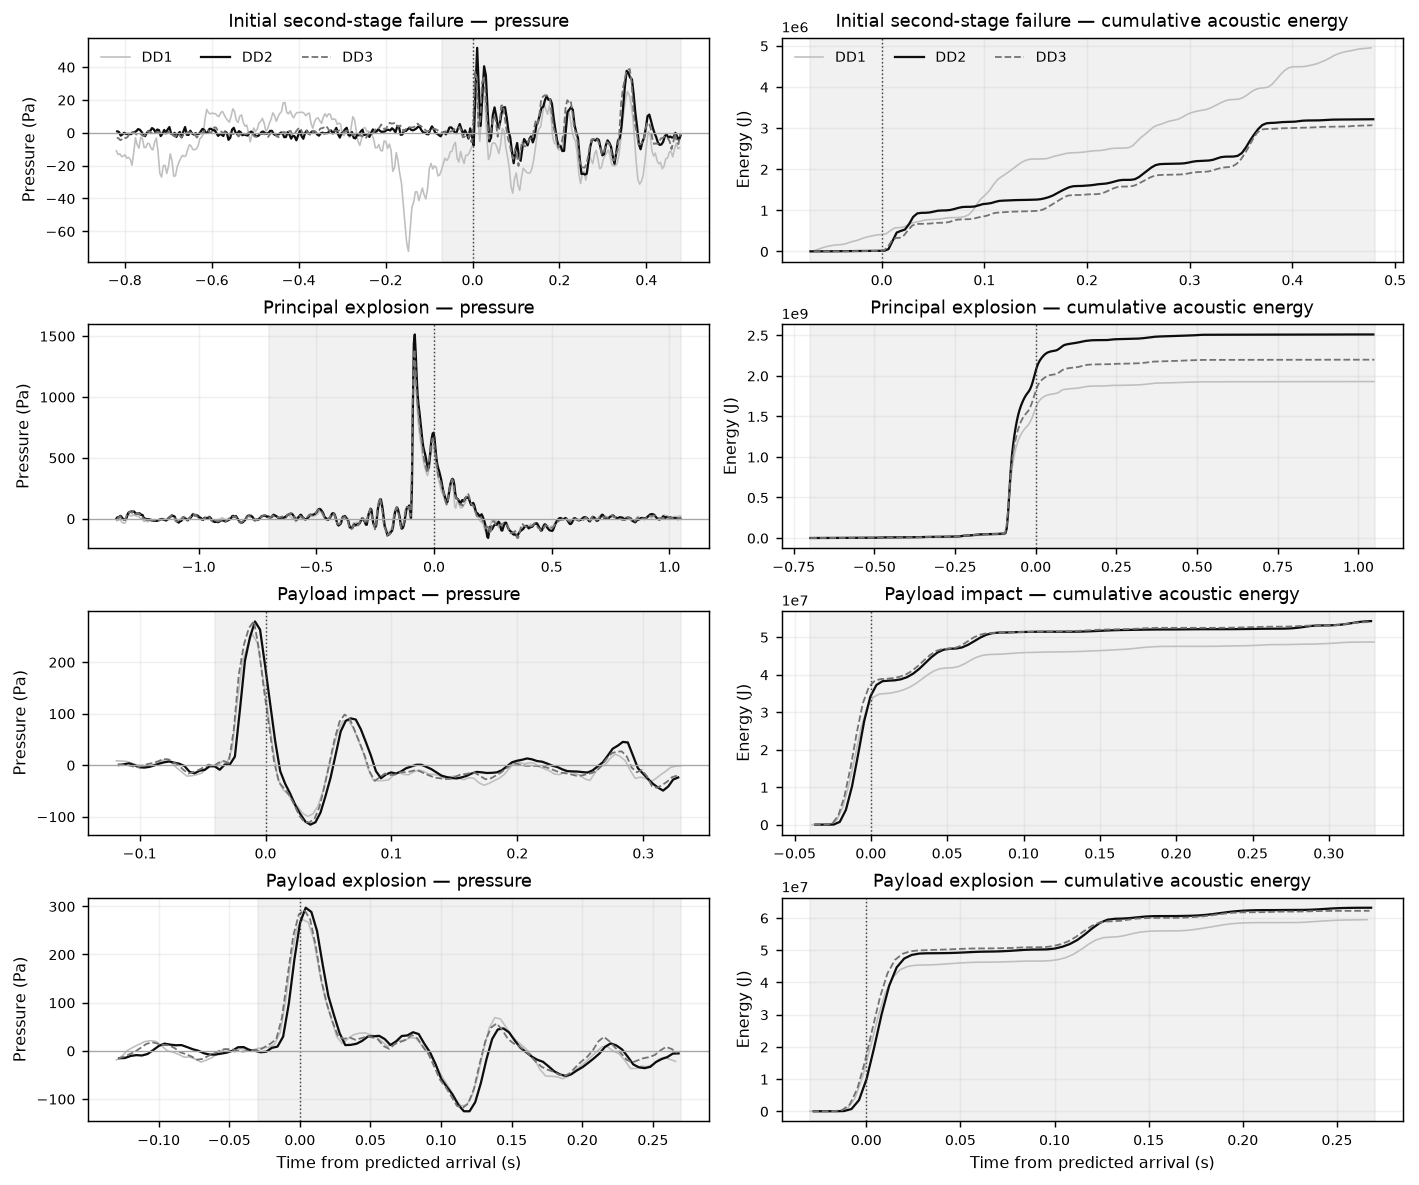

In [5]:
line_styles = {
    "DD1": dict(color="0.75", lw=0.9, ls="-"),
    "DD2": dict(color="0.05", lw=1.25, ls="-"),
    "DD3": dict(color="0.45", lw=1.0, ls="--"),
}

fig, axes = plt.subplots(
    len(event_order), 2,
    figsize=(10.8, 2.25 * len(event_order)),
    constrained_layout=True,
)

for row_index, event in enumerate(event_order):
    ax_wave, ax_energy = axes[row_index]
    records = waveform_records[event]
    signal_start = records[0]["signal_start_offset_s"]
    signal_end = records[0]["signal_end_offset_s"]

    for record in records:
        style = line_styles[record["channel"]]
        ax_wave.plot(
            record["time_s"], record["pressure_pa"],
            label=record["channel"], **style,
        )
        ax_energy.plot(
            record["signal_time_s"], record["cumulative_energy_j"],
            label=record["channel"], **style,
        )

    for ax in (ax_wave, ax_energy):
        ax.axvline(0.0, color="0.25", lw=0.8, ls=":")
        ax.axvspan(signal_start, signal_end, color="0.85", alpha=0.35, zorder=0)
        ax.grid(True, alpha=0.18)

    ax_wave.axhline(0.0, color="0.65", lw=0.7)
    ax_wave.set_ylabel("Pressure (Pa)")
    ax_energy.set_ylabel("Energy (J)")
    ax_wave.set_title(f"{event} — pressure")
    ax_energy.set_title(f"{event} — cumulative acoustic energy")
    if row_index == 0:
        ax_wave.legend(frameon=False, ncol=3, loc="upper left")
        ax_energy.legend(frameon=False, ncol=3, loc="upper left")

axes[-1, 0].set_xlabel("Time from predicted arrival (s)")
axes[-1, 1].set_xlabel("Time from predicted arrival (s)")
#fig.suptitle("Named events: pressure and passband-limited $2\\pi$ acoustic energy")

fig.savefig(
    FIGURE_DIR / "key_event_pressure_and_cumulative_acoustic_energy.pdf",
    bbox_inches="tight",
)
plt.show()


## ZRT cumulative squared ground velocity—not seismic energy

The three response-corrected seismic components are rotated from geographic
Z/N/E to source-relative Z/R/T using the SLC-40 back azimuth. The same
pressure-defined signal windows are used, referenced to the predicted acoustic
arrival at the BCHH seismometer. Consequently, these are matched-window
ground-motion diagnostics rather than complete coda integrations.

The cumulative \(\int v^2dt\) curves quantify how the recorded ground motion is
partitioned among vertical, radial, and transverse components. They are **not**
converted to joules. Most of the signal is the local ground-coupled airwave;
any direct radiated seismic energy is masked and cannot be recovered from this
single-station record without an independently constrained site-response and
wave-propagation model.

Rotation preserves N/E squared magnitude before local baseline subtraction.
Separate component-wise median baselines after rotation need not commute with
rotation; the reported corrected Z/R/T sum must not be asserted identical to a
separately median-corrected Z/N/E sum. These PGVs also use a different filter
and wider windows than the catalogue measurements in 100.


In [6]:
def unique_component(stream, component):
    component = str(component).upper()
    matches = [
        trace for trace in stream
        if str(trace.stats.channel).upper().endswith(component)
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {component} component; "
            f"found {[trace.id for trace in matches]}"
        )
    return matches[0]


st_zne = Stream([
    trace.copy()
    for trace in pressure_stream
    if str(trace.stats.channel) in SEISMIC_CHANNELS
])
if len(st_zne) != 3:
    raise ValueError(
        "Expected three response-corrected seismic components; "
        f"requested={SEISMIC_CHANNELS}, found={[tr.id for tr in st_zne]}"
    )

components = {str(trace.stats.channel)[-1].upper() for trace in st_zne}
if components != {"Z", "N", "E"}:
    raise ValueError(
        "Notebook 124 requires the canonical Z/N/E waveform product from "
        f"Notebook 010; found components={sorted(components)}"
    )

if any(np.ma.isMaskedArray(tr.data) or not np.isfinite(tr.data).all() for tr in st_zne):
    raise ValueError("Seismic integration requires complete finite samples")
seismic_gaps = st_zne.get_gaps()
if seismic_gaps:
    raise ValueError(
        "Notebook 124 expects the gap-free Z/N/E product; "
        f"found {len(seismic_gaps)} gap or overlap record(s)"
    )
common_start = max(trace.stats.starttime for trace in st_zne)
common_end = min(trace.stats.endtime for trace in st_zne)
if common_end <= common_start:
    raise ValueError("The Z/N/E components have no common time interval")
st_zne.trim(common_start, common_end, pad=False, nearest_sample=True)

sampling_rates = np.asarray(
    [float(trace.stats.sampling_rate) for trace in st_zne], dtype=float
)
npts = np.asarray([int(trace.stats.npts) for trace in st_zne], dtype=int)
start_offsets_s = np.asarray([
    float(trace.stats.starttime - st_zne[0].stats.starttime)
    for trace in st_zne
])
if not (
    np.allclose(sampling_rates, sampling_rates[0])
    and np.all(npts == npts[0])
    and np.allclose(start_offsets_s, 0.0, atol=1e-9)
):
    raise ValueError("Z/N/E traces are not sample aligned")

# This band is a declared diagnostic choice. Filtering is zero phase so the
# cumulative curves remain aligned with the predicted airwave arrival.
st_zne.detrend("linear")
st_zne.detrend("demean")
st_zne.taper(max_percentage=0.01, type="cosine")
st_zne.filter(
    "bandpass",
    freqmin=SEISMIC_EXPOSURE_FREQMIN_HZ,
    freqmax=SEISMIC_EXPOSURE_FREQMAX_HZ,
    corners=SEISMIC_EXPOSURE_FILTER_CORNERS,
    zerophase=SEISMIC_EXPOSURE_FILTER_ZEROPHASE,
)

tr_z = unique_component(st_zne, "Z")
tr_n = unique_component(st_zne, "N")
tr_e = unique_component(st_zne, "E")
r_data, t_data = rotate_ne_rt(
    np.asarray(tr_n.data, dtype=float),
    np.asarray(tr_e.data, dtype=float),
    BACK_AZIMUTH_TO_SLC40_DEG,
)

component_arrays = {
    "Z": np.asarray(tr_z.data, dtype=float),
    "R": np.asarray(r_data, dtype=float),
    "T": np.asarray(t_data, dtype=float),
}

ground_motion_rows = []
ground_motion_records = {}

for window in windows.itertuples(index=False):
    event = str(window.event)
    source_key = str(window.source_event_key)
    source_time = UTCDateTime(window.source_time_utc)
    predicted_airwave_arrival = (
        source_time + BCHH_REFERENCE_DISTANCE_M / EFFECTIVE_SOUND_SPEED_MPS
    )

    reference_arrival = UTCDateTime(window.predicted_reference_arrival_utc)
    window_start = UTCDateTime(window.window_start_utc)
    window_start_offset_s = float(window_start - reference_arrival)
    baseline_start_offset_s = (
        window_start_offset_s + float(window.baseline_start_s)
    )
    baseline_end_offset_s = (
        window_start_offset_s + float(window.baseline_end_s)
    )
    signal_start_offset_s = float(
        SIGNAL_START_OFFSET_OVERRIDES_S.get(
            source_key,
            window.signal_start_offset_from_predicted_arrival_s,
        )
    )
    signal_end_offset_s = float(
        window.signal_end_offset_from_predicted_arrival_s
    )

    times_s = np.asarray(
        tr_z.times(reftime=predicted_airwave_arrival), dtype=float
    )
    require_interval_coverage(times_s, baseline_start_offset_s, baseline_end_offset_s, f"{event} seismic baseline")
    require_interval_coverage(times_s, signal_start_offset_s, signal_end_offset_s, f"{event} seismic signal")
    finite_time = np.isfinite(times_s)
    baseline_mask = (
        finite_time
        & (times_s >= baseline_start_offset_s)
        & (times_s <= baseline_end_offset_s)
    )
    signal_mask = (
        finite_time
        & (times_s >= signal_start_offset_s)
        & (times_s <= signal_end_offset_s)
    )
    if baseline_mask.sum() < 3 or signal_mask.sum() < 3:
        raise ValueError(
            f"Insufficient seismic samples for {event}: "
            f"baseline={baseline_mask.sum()}, signal={signal_mask.sum()}"
        )

    signal_time_s = times_s[signal_mask]
    component_records = []
    signal_component_values = {}

    for component in ("Z", "R", "T"):
        values = component_arrays[component]
        baseline_velocity = float(np.nanmedian(values[baseline_mask]))
        corrected_velocity = values - baseline_velocity
        signal_velocity = corrected_velocity[signal_mask]
        signal_component_values[component] = signal_velocity

        cumulative_v2 = np.zeros(signal_velocity.size, dtype=float)
        if cumulative_v2.size > 1:
            increments = (
                0.5
                * (signal_velocity[1:]**2 + signal_velocity[:-1]**2)
                * np.diff(signal_time_s)
            )
            cumulative_v2[1:] = np.cumsum(increments)

        ground_motion_rows.append({
            "event": event,
            "source_event_key": source_key,
            "source_time_utc": source_time.isoformat(),
            "component": component,
            "back_azimuth_to_slc40_deg": BACK_AZIMUTH_TO_SLC40_DEG,
            "predicted_airwave_arrival_utc": predicted_airwave_arrival.isoformat(),
            "signal_start_offset_s": signal_start_offset_s,
            "signal_end_offset_s": signal_end_offset_s,
            "freqmin_hz": SEISMIC_EXPOSURE_FREQMIN_HZ,
            "freqmax_hz": SEISMIC_EXPOSURE_FREQMAX_HZ,
            "peak_absolute_velocity_m_s": float(np.nanmax(np.abs(signal_velocity))),
            "integrated_squared_velocity_m2_s": float(cumulative_v2[-1]),
            "quantity_is_radiated_seismic_energy": False,
        })
        component_records.append({
            "component": component,
            "signal_time_s": signal_time_s,
            "cumulative_squared_velocity_m2_s": cumulative_v2,
        })

    vector_velocity = np.sqrt(sum(
        signal_component_values[component]**2
        for component in ("Z", "R", "T")
    ))
    vector_cumulative_v2 = sum(
        record["cumulative_squared_velocity_m2_s"]
        for record in component_records
    )
    ground_motion_rows.append({
        "event": event,
        "source_event_key": source_key,
        "source_time_utc": source_time.isoformat(),
        "component": "3C vector",
        "back_azimuth_to_slc40_deg": BACK_AZIMUTH_TO_SLC40_DEG,
        "predicted_airwave_arrival_utc": predicted_airwave_arrival.isoformat(),
        "signal_start_offset_s": signal_start_offset_s,
        "signal_end_offset_s": signal_end_offset_s,
        "freqmin_hz": SEISMIC_EXPOSURE_FREQMIN_HZ,
        "freqmax_hz": SEISMIC_EXPOSURE_FREQMAX_HZ,
        "peak_absolute_velocity_m_s": float(np.nanmax(vector_velocity)),
        "integrated_squared_velocity_m2_s": float(vector_cumulative_v2[-1]),
        "quantity_is_radiated_seismic_energy": False,
    })
    component_records.append({
        "component": "3C vector",
        "signal_time_s": signal_time_s,
        "cumulative_squared_velocity_m2_s": vector_cumulative_v2,
    })
    ground_motion_records[event] = component_records

ground_motion_exposure = pd.DataFrame(ground_motion_rows)
GROUND_MOTION_OUTPUT_FILE = (
    DERIVED_DIR / "key_event_zrt_ground_motion_exposure.csv"
)
GROUND_MOTION_FIGURE_FILE = (
    FIGURE_DIR / "key_event_zrt_cumulative_squared_velocity.pdf"
)

display(ground_motion_exposure)


,event,source_event_key,source_time_utc,component,back_azimuth_to_slc40_deg,predicted_airwave_arrival_utc,signal_start_offset_s,signal_end_offset_s,freqmin_hz,freqmax_hz,peak_absolute_velocity_m_s,integrated_squared_velocity_m2_s,quantity_is_radiated_seismic_energy
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,Z,199.438026,2016-09-01T13:07:15.958261,-0.07,0.48,0.5,20.0,0.000080,5.104382e-10,False
1,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,R,199.438026,2016-09-01T13:07:15.958261,-0.07,0.48,0.5,20.0,0.000071,3.245435e-10,False
2,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,T,199.438026,2016-09-01T13:07:15.958261,-0.07,0.48,0.5,20.0,0.000022,4.859314e-11,False
3,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,3C vector,199.438026,2016-09-01T13:07:15.958261,-0.07,0.48,0.5,20.0,0.000088,8.835748e-10,False
4,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,Z,199.438026,2016-09-01T13:07:19.558861,-0.70,1.05,0.5,20.0,0.002078,7.993476e-07,False
5,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,R,199.438026,2016-09-01T13:07:19.558861,-0.70,1.05,0.5,20.0,0.001124,3.218689e-07,False
6,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,T,199.438026,2016-09-01T13:07:19.558861,-0.70,1.05,0.5,20.0,0.000386,2.992740e-08,False
7,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,3C vector,199.438026,2016-09-01T13:07:19.558861,-0.70,1.05,0.5,20.0,0.002105,1.151144e-06,False
8,Payload impact,payload_impact,2016-09-01T13:07:24.420000,Z,199.438026,2016-09-01T13:07:28.465261,-0.04,0.33,0.5,20.0,0.000449,1.261952e-08,False
9,Payload impact,payload_impact,2016-09-01T13:07:24.420000,R,199.438026,2016-09-01T13:07:28.465261,-0.04,0.33,0.5,20.0,0.000336,6.040308e-09,False


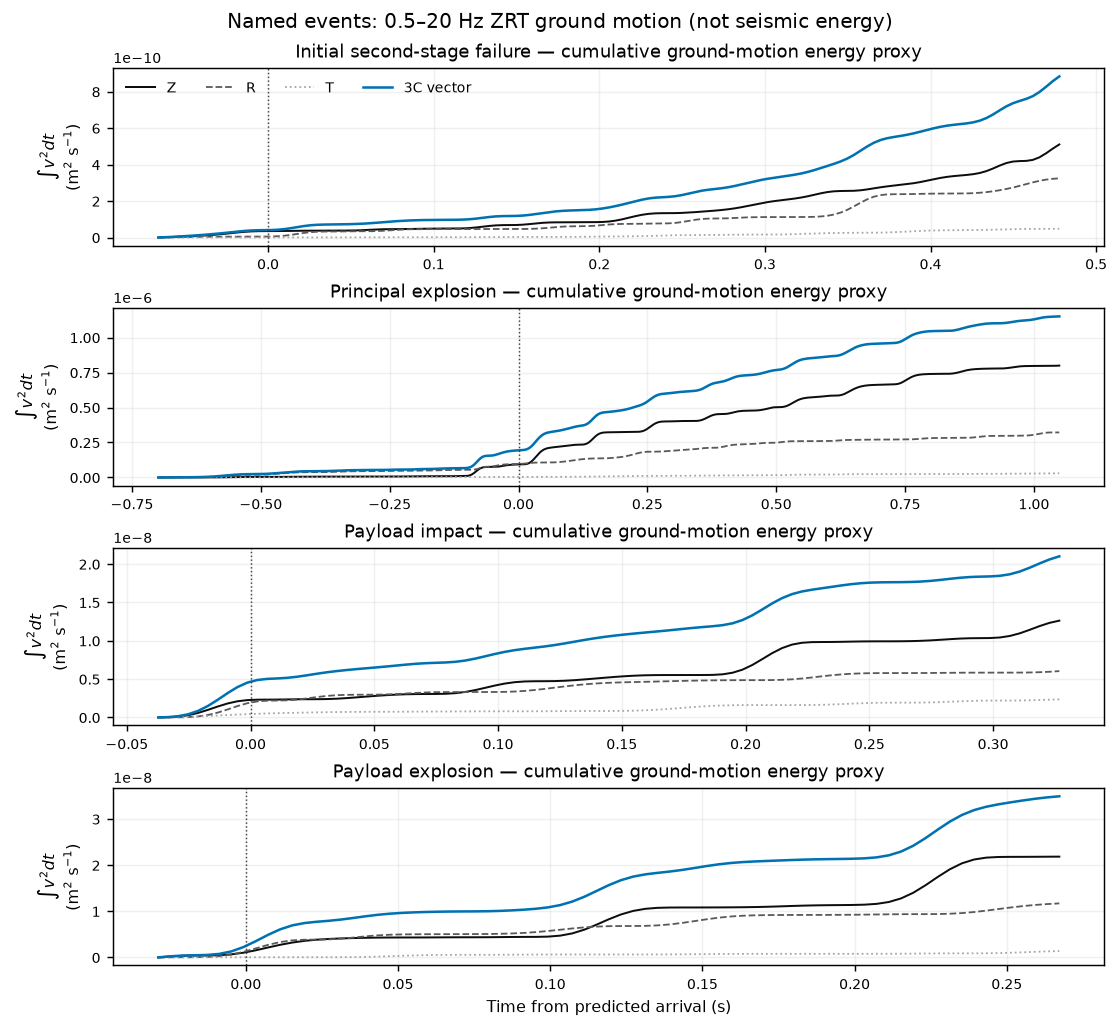

In [7]:
component_styles = {
    "Z": dict(color="0.05", lw=1.1, ls="-"),
    "R": dict(color="0.35", lw=1.0, ls="--"),
    "T": dict(color="0.65", lw=1.0, ls=":"),
    "3C vector": dict(color="#0072B2", lw=1.4, ls="-"),
}

fig, axes = plt.subplots(
    len(event_order), 1,
    figsize=(8.5, 1.95 * len(event_order)),
    sharex=False,
    constrained_layout=True,
)

for row_index, event in enumerate(event_order):
    ax = axes[row_index]
    for record in ground_motion_records[event]:
        component = record["component"]
        ax.plot(
            record["signal_time_s"],
            record["cumulative_squared_velocity_m2_s"],
            label=component,
            **component_styles[component],
        )
    ax.axvline(0.0, color="0.25", lw=0.8, ls=":")
    ax.set_ylabel(r"$\int v^2dt$" + "\n" + r"(m$^2$ s$^{-1}$)")
    ax.set_title(f"{event} — cumulative ground-motion energy proxy")
    ax.grid(True, alpha=0.18)
    if row_index == 0:
        ax.legend(frameon=False, ncol=4, loc="upper left")

axes[-1].set_xlabel("Time from predicted arrival (s)")
fig.suptitle(
    f"Named events: {SEISMIC_EXPOSURE_FREQMIN_HZ:g}–"
    f"{SEISMIC_EXPOSURE_FREQMAX_HZ:g} Hz ZRT ground motion (not seismic energy)",
    fontsize=11,
)
fig.savefig(GROUND_MOTION_FIGURE_FILE, bbox_inches="tight")
plt.show()


## Continuous integrations at two time scales

The four named-event plots above remain the appropriate products for individual
measurements. The following products answer a different question: how the
recorded passband-limited acoustic energy and ground-motion energy proxy accumulates
continuously through (1) the 30-s opening sequence and (2) the complete Phase
I–IV overview window.

Pressure time axes are reduced by each sensor's source distance divided by the
adopted 351 m s$^{-1}$ effective sound speed. The seismic time axis is reduced
by the BCHH reference distance. Consequently, the named source times and phase
intervals align with the received waveforms without changing any integral.

The continuous acoustic curves use

\[
E_{2\pi}(t)=\frac{2\pi r^2}{\rho c}\int_0^t p^2(\tau)\,d\tau.
\]

They integrate every sample, rather than only catalogue windows. For these
sequence-scale products only, pressure is additionally high-pass filtered at
0.5 Hz (four corners, zero phase) before squaring. This suppresses the
nonphysical DD1/DD3 accumulation caused by residual baseline drift. The
result is therefore a 0.5–approximately 80 Hz acoustic-energy estimate and
must not be substituted for either the broader-passband named-event values or
the de-duplicated event-only total.

The seismic curves remain cumulative $\int v^2dt$ in m$^2$ s$^{-1}$ and are
labelled a ground-motion energy proxy. They are not radiated seismic energy in joules because the direct radiated seismic field is masked by the
dominant ground-coupled airwave.

The median across sensors is taken separately for each interval/bin. Medians
are not additive, so median phase fractions need not sum to one, nor must the
sum of median bins equal the median full-window energy. Use the added
per-channel fractions for additive phase accounting. Continuous totals include
in-band ambient energy and have a 0.5-Hz high-pass; they cannot be equated
with the wider-passband named-event or catalogue-window totals.


In [8]:
def cumulative_trapezoid_values(values, times_s):
    values = np.asarray(values, dtype=float)
    times_s = np.asarray(times_s, dtype=float)
    if values.ndim != 1 or times_s.ndim != 1 or values.size != times_s.size:
        raise ValueError("values and times_s must be equal-length 1-D arrays")
    if values.size < 2 or np.any(~np.isfinite(values)) or np.any(~np.isfinite(times_s)):
        raise ValueError("continuous integration requires at least two finite samples")
    dt = np.diff(times_s)
    if np.any(dt <= 0.0):
        raise ValueError("continuous integration time must be strictly increasing")
    cumulative = np.zeros(values.size, dtype=float)
    cumulative[1:] = np.cumsum(0.5 * (values[1:] + values[:-1]) * dt)
    return cumulative


if not config.OVERVIEW_PHASE_INTERVALS:
    raise ValueError("Shared configuration must supply overview phases")
previous_end = None
for label, start, end in config.OVERVIEW_PHASE_INTERVALS:
    if end <= start or (previous_end is not None and start < previous_end):
        raise ValueError("Configured phase intervals must be ordered, positive and nonoverlapping")
    previous_end = end
FIRST_SOURCE_TIME = config.OVERVIEW_PHASE_INTERVALS[0][1]
FULL_SEQUENCE_END_S = float(
    config.OVERVIEW_PHASE_INTERVALS[-1][2] - FIRST_SOURCE_TIME
)
if OPENING_SEQUENCE_DURATION_S > FULL_SEQUENCE_END_S:
    raise ValueError("Opening sequence cannot exceed the full overview window")


def source_reduced_times(trace, distance_m):
    receiver_time_for_first_source = (
        FIRST_SOURCE_TIME + distance_m / EFFECTIVE_SOUND_SPEED_MPS
    )
    return np.asarray(
        trace.times(reftime=receiver_time_for_first_source), dtype=float
    )


def finite_window(times_s, start_s, end_s):
    require_interval_coverage(times_s, float(start_s), float(end_s), "continuous integration")
    mask = (
        np.isfinite(times_s)
        & (times_s >= float(start_s))
        & (times_s <= float(end_s))
    )
    if mask.sum() < 2:
        raise ValueError(
            f"Too few samples in continuous window {start_s:g}–{end_s:g} s"
        )
    return mask


continuous_acoustic = {}
for channel in PRESSURE_CHANNELS:
    matches = pressure_stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one continuous {channel} trace; found {len(matches)}")
    trace = matches[0].copy()
    trace.detrend("linear")
    trace.detrend("demean")
    trace.taper(max_percentage=0.01, type="cosine")
    trace.filter(
        "highpass",
        freq=CONTINUOUS_PRESSURE_HIGHPASS_HZ,
        corners=CONTINUOUS_PRESSURE_FILTER_CORNERS,
        zerophase=CONTINUOUS_PRESSURE_FILTER_ZEROPHASE,
    )
    times_s = source_reduced_times(trace, SENSOR_DISTANCES_M[channel])
    baseline_mask = finite_window(
        times_s,
        CONTINUOUS_BASELINE_WINDOW_S[0],
        CONTINUOUS_BASELINE_WINDOW_S[1],
    )
    full_mask = finite_window(times_s, 0.0, FULL_SEQUENCE_END_S)
    pressure_pa = np.asarray(trace.data, dtype=float)
    baseline_pa = float(np.nanmedian(pressure_pa[baseline_mask]))
    full_pressure_pa = pressure_pa[full_mask] - baseline_pa
    full_times_s = times_s[full_mask]
    acoustic_coefficient = (
        2.0 * np.pi * SENSOR_DISTANCES_M[channel] ** 2
        / (AIR_DENSITY_KG_M3 * EFFECTIVE_SOUND_SPEED_MPS)
    )
    cumulative_energy_j = acoustic_coefficient * cumulative_trapezoid_values(
        full_pressure_pa**2, full_times_s
    )
    continuous_acoustic[channel] = {
        "time_s": full_times_s,
        "pressure_pa": full_pressure_pa,
        "cumulative_energy_j": cumulative_energy_j,
        "constant_baseline_pa": baseline_pa,
        "highpass_hz": CONTINUOUS_PRESSURE_HIGHPASS_HZ,
    }


seismic_times_s = source_reduced_times(tr_z, BCHH_REFERENCE_DISTANCE_M)
seismic_baseline_mask = finite_window(
    seismic_times_s,
    CONTINUOUS_BASELINE_WINDOW_S[0],
    CONTINUOUS_BASELINE_WINDOW_S[1],
)
seismic_full_mask = finite_window(seismic_times_s, 0.0, FULL_SEQUENCE_END_S)

continuous_ground_motion = {}
for component in ("Z", "R", "T"):
    velocity = np.asarray(component_arrays[component], dtype=float)
    baseline_velocity = float(np.nanmedian(velocity[seismic_baseline_mask]))
    full_velocity = velocity[seismic_full_mask] - baseline_velocity
    full_times_s = seismic_times_s[seismic_full_mask]
    cumulative_exposure = cumulative_trapezoid_values(
        full_velocity**2, full_times_s
    )
    continuous_ground_motion[component] = {
        "time_s": full_times_s,
        "velocity_m_s": full_velocity,
        "cumulative_exposure_m2_s": cumulative_exposure,
        "constant_baseline_velocity_m_s": baseline_velocity,
    }

ground_time_s = continuous_ground_motion["Z"]["time_s"]
continuous_ground_motion["3C vector"] = {
    "time_s": ground_time_s,
    "cumulative_exposure_m2_s": sum(
        continuous_ground_motion[component]["cumulative_exposure_m2_s"]
        for component in ("Z", "R", "T")
    ),
}


# Common 5-s bins expose late phases that are visually compressed by the
# dominant principal-explosion step in the absolute cumulative curves.
bin_edges_s = np.arange(
    0.0,
    FULL_SEQUENCE_END_S + CONTINUOUS_BIN_WIDTH_S,
    CONTINUOUS_BIN_WIDTH_S,
)
if bin_edges_s[-1] > FULL_SEQUENCE_END_S:
    bin_edges_s[-1] = FULL_SEQUENCE_END_S
bin_edges_s = np.unique(bin_edges_s)
bin_midpoints_s = 0.5 * (bin_edges_s[:-1] + bin_edges_s[1:])


def phase_name_for_time(time_s):
    source_time = FIRST_SOURCE_TIME + float(time_s)
    for phase_label, phase_start, phase_end in config.OVERVIEW_PHASE_INTERVALS:
        if phase_start <= source_time <= phase_end:
            return phase_label
    return "Interphase"


sequence_bin_table = pd.DataFrame({
    "bin_start_source_reduced_s": bin_edges_s[:-1],
    "bin_end_source_reduced_s": bin_edges_s[1:],
    "bin_midpoint_source_reduced_s": bin_midpoints_s,
    "phase": [phase_name_for_time(value) for value in bin_midpoints_s],
})

for channel in PRESSURE_CHANNELS:
    record = continuous_acoustic[channel]
    energy_at_edges = np.interp(
        bin_edges_s, record["time_s"], record["cumulative_energy_j"]
    )
    sequence_bin_table[f"acoustic_energy_{channel.lower()}_j"] = np.diff(
        energy_at_edges
    )

acoustic_bin_columns = [
    f"acoustic_energy_{channel.lower()}_j" for channel in PRESSURE_CHANNELS
]
sequence_bin_table["median_acoustic_energy_j"] = sequence_bin_table[
    acoustic_bin_columns
].median(axis=1)

ground_energy_at_edges = np.interp(
    bin_edges_s,
    continuous_ground_motion["3C vector"]["time_s"],
    continuous_ground_motion["3C vector"]["cumulative_exposure_m2_s"],
)
sequence_bin_table["ground_motion_exposure_3c_m2_s"] = np.diff(
    ground_energy_at_edges
)


def interval_summary_row(interval, interval_type, start_s, end_s):
    row = {
        "interval": interval,
        "interval_type": interval_type,
        "start_source_reduced_s": start_s,
        "end_source_reduced_s": end_s,
        "duration_s": end_s - start_s,
    }
    channel_totals = []
    for channel in PRESSURE_CHANNELS:
        record = continuous_acoustic[channel]
        values = np.interp(
            [start_s, end_s],
            record["time_s"],
            record["cumulative_energy_j"],
        )
        phase_energy = float(values[1] - values[0])
        row[f"acoustic_energy_{channel.lower()}_j"] = phase_energy
        channel_totals.append(phase_energy)
    row["median_acoustic_energy_j"] = float(np.median(channel_totals))
    ground_record = continuous_ground_motion["3C vector"]
    values = np.interp(
        [start_s, end_s],
        ground_record["time_s"],
        ground_record["cumulative_exposure_m2_s"],
    )
    row["ground_motion_exposure_3c_m2_s"] = float(values[1] - values[0])
    row["quantity_is_radiated_seismic_energy"] = False
    return row


opening_row = interval_summary_row(
    "Opening sequence", "overview", 0.0, OPENING_SEQUENCE_DURATION_S
)
full_sequence_row = interval_summary_row(
    "Full overview window", "overview", 0.0, FULL_SEQUENCE_END_S
)
phase_rows = []
for phase_label, phase_start, phase_end in config.OVERVIEW_PHASE_INTERVALS:
    phase_rows.append(interval_summary_row(
        phase_label,
        "phase",
        float(phase_start - FIRST_SOURCE_TIME),
        float(phase_end - FIRST_SOURCE_TIME),
    ))

# Do not silently force all sequence energy into the four descriptive phase
# windows. Report the complement explicitly; this also reveals whether phase
# boundaries need reconsideration after filtering.
outside_row = {
    "interval": "Outside Phases I–IV",
    "interval_type": "complement",
    "start_source_reduced_s": 0.0,
    "end_source_reduced_s": FULL_SEQUENCE_END_S,
    "duration_s": FULL_SEQUENCE_END_S - sum(
        row["duration_s"] for row in phase_rows
    ),
    "quantity_is_radiated_seismic_energy": False,
}
for channel in PRESSURE_CHANNELS:
    key = f"acoustic_energy_{channel.lower()}_j"
    outside_row[key] = float(
        full_sequence_row[key] - sum(row[key] for row in phase_rows)
    )
outside_row["median_acoustic_energy_j"] = float(np.median([
    outside_row[f"acoustic_energy_{channel.lower()}_j"]
    for channel in PRESSURE_CHANNELS
]))
outside_row["ground_motion_exposure_3c_m2_s"] = float(
    full_sequence_row["ground_motion_exposure_3c_m2_s"]
    - sum(row["ground_motion_exposure_3c_m2_s"] for row in phase_rows)
)

interval_rows = [opening_row, full_sequence_row, *phase_rows, outside_row]
if hasattr(config, "OVERVIEW_PROLONGED_SIGNAL_INTERVAL"):
    prolonged_start, prolonged_end = config.OVERVIEW_PROLONGED_SIGNAL_INTERVAL
    interval_rows.append(interval_summary_row(
        "Prolonged signal",
        "diagnostic",
        float(prolonged_start - FIRST_SOURCE_TIME),
        float(prolonged_end - FIRST_SOURCE_TIME),
    ))

sequence_interval_totals = pd.DataFrame(interval_rows)
full_acoustic_energy_j = float(full_sequence_row["median_acoustic_energy_j"])
full_ground_exposure = float(
    full_sequence_row["ground_motion_exposure_3c_m2_s"]
)
sequence_interval_totals["fraction_of_full_acoustic_energy"] = (
    sequence_interval_totals["median_acoustic_energy_j"]
    / full_acoustic_energy_j
)
for channel in PRESSURE_CHANNELS:
    column = f"acoustic_energy_{channel.lower()}_j"
    sequence_interval_totals[f"fraction_of_full_acoustic_energy_{channel.lower()}"] = (
        sequence_interval_totals[column] / full_sequence_row[column]
    )
sequence_interval_totals["fraction_of_full_ground_exposure"] = (
    sequence_interval_totals["ground_motion_exposure_3c_m2_s"]
    / full_ground_exposure
)
SEQUENCE_BIN_OUTPUT_FILE = DERIVED_DIR / "continuous_sequence_5s_energy_bins.csv"
SEQUENCE_INTERVAL_OUTPUT_FILE = (
    DERIVED_DIR / "continuous_sequence_interval_totals.csv"
)
OPENING_SEQUENCE_FIGURE_FILE = (
    FIGURE_DIR / "opening_sequence_cumulative_acoustic_and_ground_motion.pdf"
)
FULL_SEQUENCE_FIGURE_FILE = (
    FIGURE_DIR / "full_sequence_cumulative_acoustic_and_ground_motion.pdf"
)

interval_display = sequence_interval_totals[[
    "interval", "duration_s", "acoustic_energy_dd1_j",
    "acoustic_energy_dd2_j", "acoustic_energy_dd3_j",
    "median_acoustic_energy_j", "fraction_of_full_acoustic_energy",
    "ground_motion_exposure_3c_m2_s",
    "fraction_of_full_ground_exposure",
]].copy()
display(interval_display.style.format({
    "duration_s": "{:.1f}",
    "acoustic_energy_dd1_j": "{:.3e}",
    "acoustic_energy_dd2_j": "{:.3e}",
    "acoustic_energy_dd3_j": "{:.3e}",
    "median_acoustic_energy_j": "{:.3e}",
    "fraction_of_full_acoustic_energy": "{:.1%}",
    "ground_motion_exposure_3c_m2_s": "{:.3e}",
    "fraction_of_full_ground_exposure": "{:.1%}",
}))


,interval,duration_s,acoustic_energy_dd1_j,acoustic_energy_dd2_j,acoustic_energy_dd3_j,median_acoustic_energy_j,fraction_of_full_acoustic_energy,ground_motion_exposure_3c_m2_s,fraction_of_full_ground_exposure
0,Opening sequence,30.0,1.973e+09,2.431e+09,2.179e+09,2.179e+09,54.5%,2.475e-06,96.1%
1,Full overview window,1662.1,7.042e+09,2.693e+09,3.998e+09,3.998e+09,100.0%,2.574e-06,100.0%
2,Phase I,70.0,2.086e+09,2.442e+09,2.243e+09,2.243e+09,56.1%,2.483e-06,96.5%
3,Phase II,110.0,5.165e+08,5.389e+07,1.493e+08,1.493e+08,3.7%,3.834e-08,1.5%
4,Phase III,358.0,7.575e+08,6.447e+07,4.264e+08,4.264e+08,10.7%,2.747e-08,1.1%
5,Phase IV,315.0,7.571e+08,3.212e+07,3.069e+08,3.069e+08,7.7%,3.871e-09,0.2%
6,Outside Phases I–IV,809.1,2.924e+09,1.002e+08,8.714e+08,8.714e+08,21.8%,2.170e-08,0.8%
7,Prolonged signal,192.0,7.226e+08,4.417e+07,1.336e+08,1.336e+08,3.3%,1.708e-08,0.7%


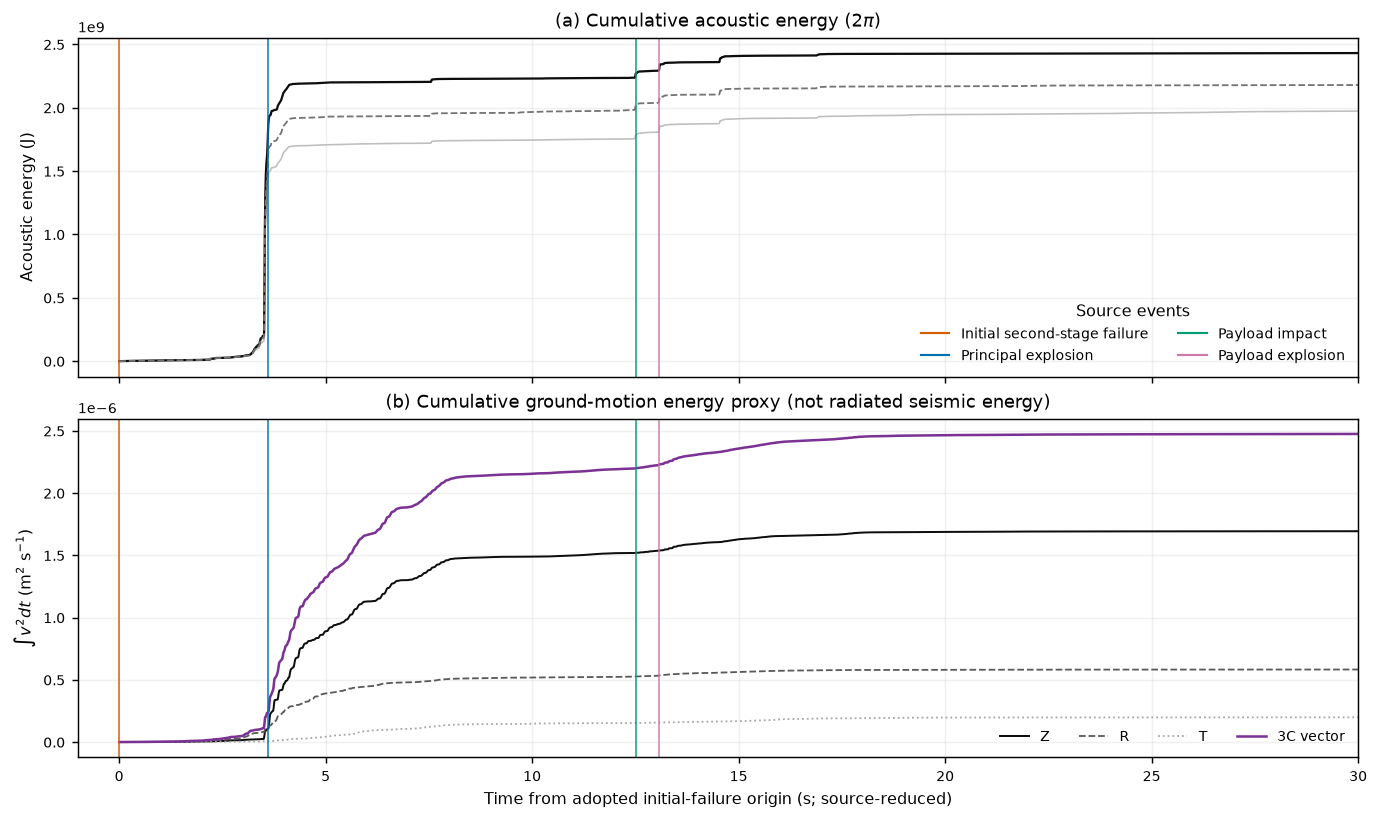

In [9]:
opening_event_colors = {
    event: color
    for event, color in zip(
        event_order,
        ("#D55E00", "#0072B2", "#009E73", "#CC79A7"),
    )
}
opening_event_offsets_s = {
    str(row.event): float(UTCDateTime(row.source_time_utc) - FIRST_SOURCE_TIME)
    for row in windows.drop_duplicates("event").itertuples(index=False)
    if str(row.event) in event_order
}

# Use a neutral/purple tone for the cumulative 3C proxy so it cannot be
# confused with the blue principal-explosion timing marker.
opening_component_styles = {key: dict(value) for key, value in component_styles.items()}
opening_component_styles["3C vector"] = dict(color="#7B3294", lw=1.4, ls="-")

fig, axes = plt.subplots(
    2, 1, figsize=(10.5, 6.2), sharex=True, constrained_layout=True
)

for channel in PRESSURE_CHANNELS:
    record = continuous_acoustic[channel]
    mask = record["time_s"] <= OPENING_SEQUENCE_DURATION_S
    axes[0].plot(
        record["time_s"][mask],
        record["cumulative_energy_j"][mask],
        label=channel,
        **line_styles[channel],
    )

for component in ("Z", "R", "T", "3C vector"):
    record = continuous_ground_motion[component]
    mask = record["time_s"] <= OPENING_SEQUENCE_DURATION_S
    axes[1].plot(
        record["time_s"][mask],
        record["cumulative_exposure_m2_s"][mask],
        label=component,
        **opening_component_styles[component],
    )

for axis in axes:
    for event, event_time_s in opening_event_offsets_s.items():
        axis.axvline(
            event_time_s,
            color=opening_event_colors[event],
            lw=0.9,
            alpha=0.9,
        )
    axis.grid(True, alpha=0.18)
    # The initial-failure marker is exactly t=0. A short negative margin keeps
    # it from being hidden beneath the left axis spine.
    axis.set_xlim(-OPENING_SEQUENCE_LEFT_MARGIN_S, OPENING_SEQUENCE_DURATION_S)

event_handles = [
    Line2D([0], [0], color=opening_event_colors[event], lw=1.2, label=event)
    for event in event_order
]
axes[0].legend(
    handles=event_handles,
    frameon=False,
    ncol=2,
    loc="lower right",
    title="Source events",
)
axes[0].set_ylabel("Acoustic energy (J)")
axes[0].set_title("(a) Cumulative acoustic energy ($2\\pi$)")
axes[1].set_ylabel(r"$\int v^2dt$ (m$^2$ s$^{-1}$)")
axes[1].set_title("(b) Cumulative ground-motion energy proxy (not radiated seismic energy)")
axes[1].set_xlabel("Time from adopted initial-failure origin (s; source-reduced)")
axes[1].legend(frameon=False, ncol=4, loc="lower right")
'''fig.suptitle(
    f"Opening {OPENING_SEQUENCE_DURATION_S:g}-s sequence "
    "(origin times inferred, not directly observed at the source)"
)'''
fig.savefig(OPENING_SEQUENCE_FIGURE_FILE, bbox_inches="tight")
plt.show()


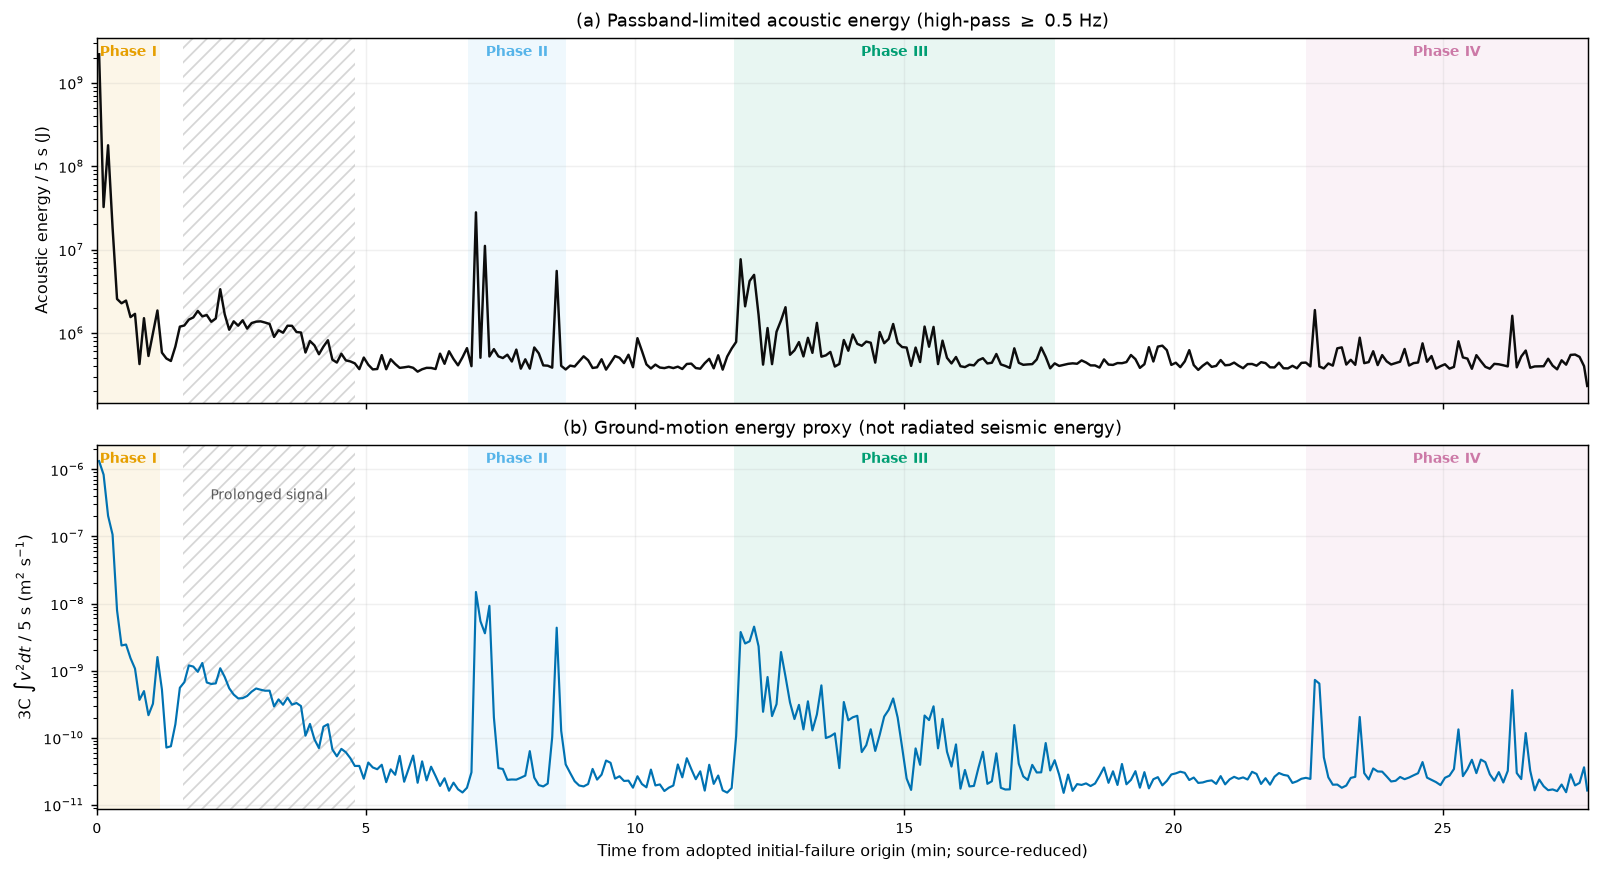

In [10]:
phase_colors = {
    "Phase I": "#E69F00",
    "Phase II": "#56B4E9",
    "Phase III": "#009E73",
    "Phase IV": "#CC79A7",
}


def add_phase_spans(axis, add_labels=False):
    for phase_label, phase_start, phase_end in config.OVERVIEW_PHASE_INTERVALS:
        start_min = float(phase_start - FIRST_SOURCE_TIME) / 60.0
        end_min = float(phase_end - FIRST_SOURCE_TIME) / 60.0
        axis.axvspan(
            start_min,
            end_min,
            color=phase_colors[phase_label],
            alpha=0.09,
            lw=0,
            zorder=0,
        )
        if add_labels:
            axis.text(
                0.5 * (start_min + end_min),
                0.98,
                phase_label,
                transform=axis.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=8,
                color=phase_colors[phase_label],
                fontweight="bold",
            )


def add_prolonged_signal_span(axis, add_label=False):
    if not hasattr(config, "OVERVIEW_PROLONGED_SIGNAL_INTERVAL"):
        return
    start, end = config.OVERVIEW_PROLONGED_SIGNAL_INTERVAL
    start_min = float(start - FIRST_SOURCE_TIME) / 60.0
    end_min = float(end - FIRST_SOURCE_TIME) / 60.0
    axis.axvspan(
        start_min,
        end_min,
        facecolor="none",
        edgecolor="0.55",
        hatch="///",
        lw=0.0,
        alpha=0.35,
        zorder=0,
    )
    if add_label:
        axis.text(
            0.5 * (start_min + end_min),
            0.88,
            "Prolonged signal",
            transform=axis.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8,
            color="0.35",
        )


# The principal explosion dominates absolute cumulative plots. The larger
# rate panels show the temporal structure; exact cumulative totals are in the
# displayed/exported interval table.
fig, axes = plt.subplots(
    2, 1, figsize=(12.2, 6.6), sharex=True, constrained_layout=True
)

bin_time_min = (
    sequence_bin_table["bin_midpoint_source_reduced_s"].to_numpy(float)
    / 60.0
)
# DD2 is the cleanest continuous pressure channel after high-pass filtering.
# Plot it alone here so late-phase structure is not obscured by noisier DD1/DD3
# traces or by a redundant channel-median curve. Phase spans are read directly
# from project_config.py, so boundary changes should be made there.
dd2_increment = sequence_bin_table["acoustic_energy_dd2_j"].to_numpy(float)
axes[0].plot(
    bin_time_min,
    np.where(dd2_increment > 0.0, dd2_increment, np.nan),
    color=line_styles["DD2"]["color"],
    lw=1.35,
)

ground_increment = sequence_bin_table[
    "ground_motion_exposure_3c_m2_s"
].to_numpy(float)
axes[1].plot(
    bin_time_min,
    np.where(ground_increment > 0.0, ground_increment, np.nan),
    color=component_styles["3C vector"]["color"],
    lw=1.2,
    label="3C vector",
)

for axis_index, axis in enumerate(axes):
    add_phase_spans(axis, add_labels=True)
    add_prolonged_signal_span(axis, add_label=(axis_index == 1))
    axis.grid(True, alpha=0.18)
    axis.set_xlim(0.0, FULL_SEQUENCE_END_S / 60.0)
    axis.set_yscale("log")

axes[0].set_ylabel(f"Acoustic energy / {CONTINUOUS_BIN_WIDTH_S:g} s (J)")
axes[0].set_title(
    f"(a) Passband-limited acoustic energy (high-pass $\\geq$ "
    f"{CONTINUOUS_PRESSURE_HIGHPASS_HZ:g} Hz)"
)
'''
axes[0].text(
    0.995,
    0.73,
    f"DD2 full-window: {full_sequence_row['acoustic_energy_dd2_j']:.2e} J",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=8,
    bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.85),
)
'''

axes[1].set_ylabel(
    f"3C $\\int v^2dt$ / {CONTINUOUS_BIN_WIDTH_S:g} s "
    r"(m$^2$ s$^{-1}$)"
)
axes[1].set_title("(b) Ground-motion energy proxy (not radiated seismic energy)")
axes[1].set_xlabel(
    "Time from adopted initial-failure origin (min; source-reduced)"
)
#fig.suptitle("Sequence energy-release and ground-motion-proxy rates")
fig.savefig(FULL_SEQUENCE_FIGURE_FILE, bbox_inches="tight")
plt.show()


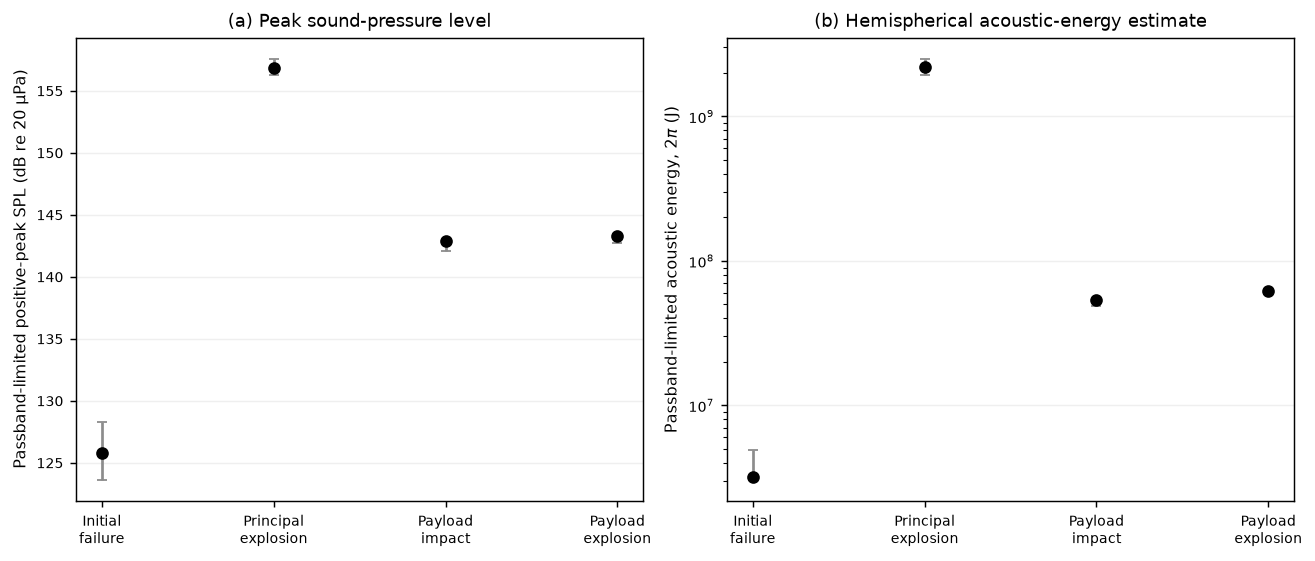

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2), constrained_layout=True)
x = np.arange(len(energetics_summary))

spl_median = energetics_summary["median_positive_peak_spl_db"].to_numpy(float)
spl_low = energetics_summary["minimum_positive_peak_spl_db"].to_numpy(float)
spl_high = energetics_summary["maximum_positive_peak_spl_db"].to_numpy(float)
axes[0].errorbar(
    x, spl_median,
    yerr=np.vstack([spl_median - spl_low, spl_high - spl_median]),
    fmt="o", color="black", ecolor="0.55", capsize=3,
)
axes[0].set_ylabel("Passband-limited positive-peak SPL (dB re 20 µPa)")
axes[0].set_title("(a) Peak sound-pressure level")

energy_median = energetics_summary["median_acoustic_energy_2pi_j"].to_numpy(float)
energy_low = energetics_summary["minimum_acoustic_energy_2pi_j"].to_numpy(float)
energy_high = energetics_summary["maximum_acoustic_energy_2pi_j"].to_numpy(float)
axes[1].errorbar(
    x, energy_median,
    yerr=np.vstack([energy_median - energy_low, energy_high - energy_median]),
    fmt="o", color="black", ecolor="0.55", capsize=3,
)
axes[1].set_yscale("log")
axes[1].set_ylabel("Passband-limited acoustic energy, $2\\pi$ (J)")
axes[1].set_title("(b) Hemispherical acoustic-energy estimate")

short_labels = [
    "Initial\nfailure", "Principal\nexplosion",
    "Payload\nimpact", "Payload\nexplosion",
]
for ax in axes:
    ax.set_xticks(x, short_labels)
    ax.grid(True, axis="y", alpha=0.2)

fig.savefig(
    FIGURE_DIR / "key_event_spl_and_acoustic_energy_summary.pdf",
    bbox_inches="tight",
)
plt.show()

## Weak-shock propagation diagnostic

The compact array provides a **local horizontal apparent propagation speed**;
it does not require an explosion origin time. Conversely, a source-to-array
mean speed requires an independently known source onset, which is unavailable
here. The adopted event origins are inferred by travel-time reduction and must
not be treated as direct source recordings.

The pressure jump supplies a separate test. For a normal shock,

\[
M=\left[1+\frac{\gamma+1}{2\gamma}\frac{\Delta p}{p_0}\right]^{1/2}.
\]

At the measured array overpressure this should be only a weakly nonlinear
correction to the meteorological sound speed. The inward extrapolation below
assumes \(\Delta p\propto r^{-1}\). It is shown only as a sensitivity model:
far-field spherical spreading is not a validated near-source blast model, and
the calculation cannot recover the true source pressure or onset time.

### Interpretation alongside array-speed estimates

The preferred time-domain planar solution for the principal explosion is not a
high-speed outlier: it is about 352.5 m s$^{-1}$, essentially the same as the
high-quality-event coherence-weighted value of about 352 m s$^{-1}$. A
short-window Bartlett estimate using the same record is higher (about 369.4 m s$^{-1}$)
but has only modest $F$ (about 4.49), so it should be treated as suggestive
rather than definitive. The two array methods therefore do not justify a claim
that the blast remained substantially supersonic at BCHH.

Taken together, however, the high-side Bartlett speed, the tendency for a fixed
351 m s$^{-1}$ reduction to place the pressure onset slightly earlier than
video-based onset estimates, the rapid compression--rarefaction
(Friedlander-like) waveform, and the weak-shock sensitivity calculation are
all compatible with a nonlinear wave that was stronger nearer the source and
had decayed to a very weak shock by 1.4 km. The fixed-speed timing reduction
should therefore remain explicitly labelled as an adopted/inferred source-time
coordinate, not a direct source observation.

The Bartlett and time-domain estimates share waveform data. Video timing
anchored to an adopted seismic/acoustic event is not an independent source
clock; timing offsets from that anchoring cannot independently establish a
path-averaged shock speed. The inward 1/r extrapolation is conditional and
its path-average value is not an observational estimate.


,value
principal_positive_overpressure_pa,1390.287608
ambient_pressure_pa,101325.0
still_air_sound_speed_mps,348.329579
wind_along_ray_mps,2.647354
linear_effective_sound_speed_mps,350.976933
local_mach_at_array,1.005863
local_shock_speed_at_array_still_air_mps,350.37193
local_shock_speed_at_array_with_wind_mps,353.019284
modeled_path_average_speed_still_air_mps,357.156738
modeled_path_average_speed_with_wind_mps,359.804092


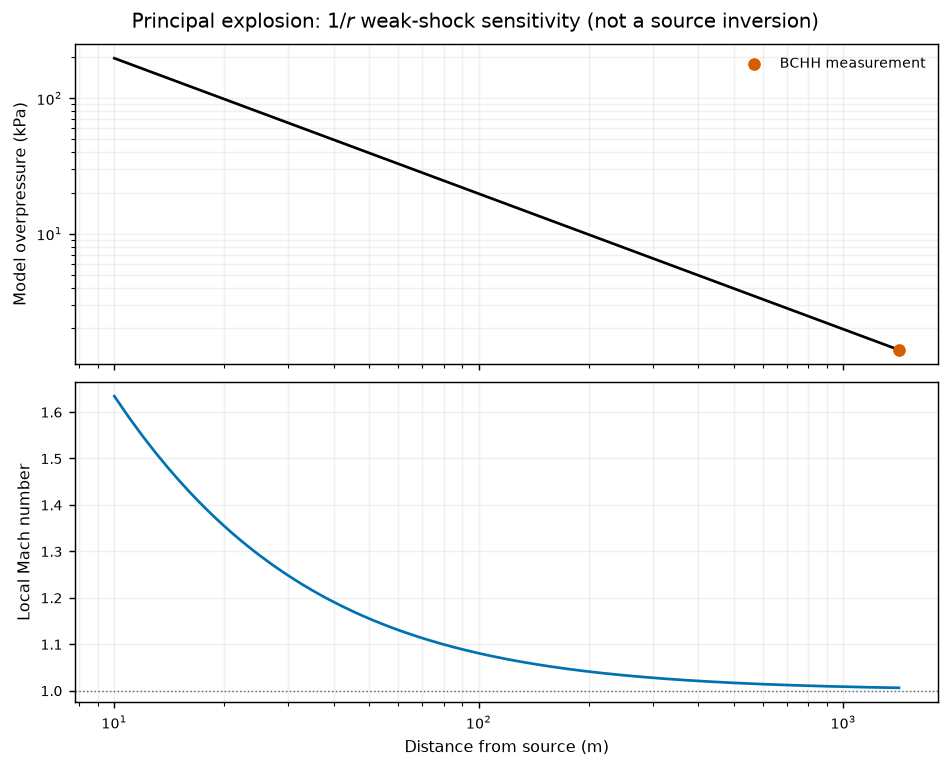

In [12]:
from modules.physics import mach_vs_overpressure

principal_row = energetics_summary.loc[
    energetics_summary["source_event_key"] == "lower_stage"
]
if len(principal_row) != 1:
    raise ValueError(
        "Expected one lower_stage/principal-explosion energetics row; "
        f"found {len(principal_row)}"
    )

principal_positive_overpressure_pa = float(
    principal_row.iloc[0]["median_positive_peak_pa"]
)
still_air_sound_speed_mps = float(weather_summary["still_air_sound_speed_mps"])
wind_along_ray_mps = float(weather_summary["wind_along_ray_mps"])

shock_model = mach_vs_overpressure(
    speed_of_sound=still_air_sound_speed_mps,
    gamma=1.4,
    ambient_pressure=ATMOSPHERIC_PRESSURE_PA,
    reference_distance=BCHH_REFERENCE_DISTANCE_M,
    reference_overpressure=principal_positive_overpressure_pa,
    minimum_model_distance=10.0,
    distance_step=1.0,
    spreading_exponent=1.0,
)

shock_summary = pd.DataFrame([{
    "principal_positive_overpressure_pa": principal_positive_overpressure_pa,
    "ambient_pressure_pa": ATMOSPHERIC_PRESSURE_PA,
    "still_air_sound_speed_mps": still_air_sound_speed_mps,
    "wind_along_ray_mps": wind_along_ray_mps,
    "linear_effective_sound_speed_mps": (
        still_air_sound_speed_mps + wind_along_ray_mps
    ),
    "local_mach_at_array": shock_model["mach_at_array"],
    "local_shock_speed_at_array_still_air_mps": (
        shock_model["local_speed_at_array_mps"]
    ),
    "local_shock_speed_at_array_with_wind_mps": (
        shock_model["local_speed_at_array_mps"] + wind_along_ray_mps
    ),
    "modeled_path_average_speed_still_air_mps": (
        shock_model["path_average_speed_mps"]
    ),
    "modeled_path_average_speed_with_wind_mps": (
        shock_model["path_average_speed_mps"] + wind_along_ray_mps
    ),
    "minimum_model_distance_m": shock_model["minimum_model_distance_m"],
    "spreading_exponent": shock_model["spreading_exponent"],
    "true_source_pressure_retrievable": False,
}])
display(shock_summary.T.rename(columns={0: "value"}))

shock_profile = pd.DataFrame({
    "distance_m": shock_model["distance"],
    "model_overpressure_pa": shock_model["pressure_along_ray"],
    "local_mach": shock_model["mach_along_ray"],
    "local_shock_speed_still_air_mps": (
        shock_model["local_speed_along_ray_mps"]
    ),
})

SHOCK_SUMMARY_OUTPUT_FILE = DERIVED_DIR / "principal_explosion_weak_shock_summary.csv"
SHOCK_PROFILE_OUTPUT_FILE = DERIVED_DIR / "principal_explosion_weak_shock_profile.csv"
SHOCK_FIGURE_FILE = FIGURE_DIR / "principal_explosion_weak_shock_sensitivity.pdf"

fig, axes = plt.subplots(2, 1, figsize=(7.2, 5.8), sharex=True, constrained_layout=True)
axes[0].plot(
    shock_profile["distance_m"],
    shock_profile["model_overpressure_pa"] / 1000.0,
    color="black",
)
axes[0].scatter(
    [BCHH_REFERENCE_DISTANCE_M],
    [principal_positive_overpressure_pa / 1000.0],
    color="#D55E00",
    zorder=3,
    label="BCHH measurement",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Model overpressure (kPa)")
axes[0].legend(frameon=False)

axes[1].plot(
    shock_profile["distance_m"],
    shock_profile["local_mach"],
    color="#0072B2",
)
axes[1].axhline(1.0, color="0.4", lw=0.8, ls=":")
axes[1].set_xscale("log")
axes[1].set_xlabel("Distance from source (m)")
axes[1].set_ylabel("Local Mach number")
for axis in axes:
    axis.grid(True, which="both", alpha=0.18)
fig.suptitle("Principal explosion: $1/r$ weak-shock sensitivity (not a source inversion)")
fig.savefig(SHOCK_FIGURE_FILE, bbox_inches="tight")
plt.show()


## Export and safeguards

The channel table is the authoritative numerical output. The event table
reports the median and channel range. SPL and acoustic energy are limited to
the usable infraBSU and processing passband. The \(2\pi\) acoustic energy is
the primary estimate; the \(4\pi\) value is an explicit geometrical sensitivity
result. Efficiency-scaled TNT values are scenarios, not measured yields.

The ZRT table contains peak ground velocity and cumulative \(\int v^2dt\) over
the same pressure-defined windows in the declared 0.5–20 Hz diagnostic band.
It must not be labelled radiated seismic energy or converted to source joules:
the dominant motion is the local ground-coupled airwave and masks any
separable direct seismic contribution.


The continuous 5-s table supports the phase-resolving panels. The interval
table reports exact totals for the opening sequence, the full Phase I–IV
window, and each individual phase. Continuous acoustic totals include all
samples in their stated intervals and therefore are not interchangeable with
the de-duplicated catalogue-window energy estimate.


In [13]:
CHANNEL_OUTPUT_FILE = DERIVED_DIR / "key_event_acoustic_energetics_by_channel.csv"
SUMMARY_OUTPUT_FILE = DERIVED_DIR / "key_event_acoustic_energetics_summary.csv"
METADATA_OUTPUT_FILE = DERIVED_DIR / "key_event_acoustic_energetics_metadata.json"

energetics_by_channel.to_csv(CHANNEL_OUTPUT_FILE, index=False)
energetics_summary.to_csv(SUMMARY_OUTPUT_FILE, index=False)

ground_motion_exposure.to_csv(GROUND_MOTION_OUTPUT_FILE, index=False)
sequence_bin_table.to_csv(SEQUENCE_BIN_OUTPUT_FILE, index=False)
sequence_interval_totals.to_csv(SEQUENCE_INTERVAL_OUTPUT_FILE, index=False)
shock_summary.to_csv(SHOCK_SUMMARY_OUTPUT_FILE, index=False)
shock_profile.to_csv(SHOCK_PROFILE_OUTPUT_FILE, index=False)

metadata = {
    "output_path_compatibility": "shared config.NB120_DIR retained for downstream consumers",
    "phase_definitions": "config.OVERVIEW_PHASE_INTERVALS; unchanged descriptive source-time intervals",
    "named_window_convention": "per-sensor predicted arrivals, inclusive baseline endpoints; distinct from 110 unshifted snapped windows",
    "channel_range_interpretation": "sensor dispersion, not confidence intervals; geometry, baseline, calibration and beyond-nominal-range linearity add uncertainty",
    "median_interval_accounting": "interval/bin medians are not additive; use per-channel fractions for phase accounting",
    "producer_notebook": "124_estimate_acoustic_energetics.ipynb",
    "pressure_stream_file": str(PRESSURE_STREAM_FILE),
    "notebook11_window_file": str(WINDOW_FILE),
    "notebook11_metadata_file": str(NOTEBOOK11_METADATA_FILE),
    "weather_summary_file": str(WEATHER_SUMMARY_FILE),
    "pressure_channels": list(PRESSURE_CHANNELS),
    "pressure_response_prefilters_hz": PRESSURE_RESPONSE_PREFILTERS_HZ,
    "acoustic_results_are_passband_limited": True,
    "seismic_channels": list(SEISMIC_CHANNELS),
    "sensor_distances_m": SENSOR_DISTANCES_M,
    "effective_sound_speed_mps": EFFECTIVE_SOUND_SPEED_MPS,
    "atmospheric_pressure_pa_assumed": ATMOSPHERIC_PRESSURE_PA,
    "mean_temperature_c": temperature_c,
    "mean_relative_humidity_percent": 100.0 * relative_humidity_fraction,
    "computed_air_density_kg_m3": AIR_DENSITY_KG_M3,
    "reference_pressure_pa": REFERENCE_PRESSURE_PA,
    "reference_exposure_time_s": REFERENCE_EXPOSURE_TIME_S,
    "primary_radiation_solid_angle_sr": 2.0 * np.pi,
    "sensitivity_radiation_solid_angle_sr": 4.0 * np.pi,
    "joules_per_kg_tnt": JOULES_PER_KG_TNT,
    "acoustic_efficiency_reference": ACOUSTIC_EFFICIENCY_REFERENCE,
    "acoustic_efficiency_range": list(ACOUSTIC_EFFICIENCY_RANGE),
    "signal_start_offset_overrides_s": SIGNAL_START_OFFSET_OVERRIDES_S,
    "ground_motion_energy_proxy_diagnostic": {
        "coordinates": "ZRT",
        "back_azimuth_to_slc40_deg": BACK_AZIMUTH_TO_SLC40_DEG,
        "freqmin_hz": SEISMIC_EXPOSURE_FREQMIN_HZ,
        "freqmax_hz": SEISMIC_EXPOSURE_FREQMAX_HZ,
        "filter_corners": SEISMIC_EXPOSURE_FILTER_CORNERS,
        "zerophase": SEISMIC_EXPOSURE_FILTER_ZEROPHASE,
        "quantity": "cumulative integral of squared ground velocity",
        "units": "m^2 s^-1",
        "radiated_seismic_energy_retrievable": False,
        "reason": (
            "Direct seismic radiation is masked by dominant local "
            "ground-coupled-airwave motion at the single station."
        ),
    },
    "continuous_integrations": {
        "opening_sequence_duration_s": OPENING_SEQUENCE_DURATION_S,
        "opening_sequence_left_margin_s": OPENING_SEQUENCE_LEFT_MARGIN_S,
        "full_sequence_duration_s": FULL_SEQUENCE_END_S,
        "bin_width_s": CONTINUOUS_BIN_WIDTH_S,
        "pressure_highpass_hz": CONTINUOUS_PRESSURE_HIGHPASS_HZ,
        "pressure_filter_corners": CONTINUOUS_PRESSURE_FILTER_CORNERS,
        "pressure_filter_zerophase": CONTINUOUS_PRESSURE_FILTER_ZEROPHASE,
        "constant_baseline_window_source_reduced_s": list(
            CONTINUOUS_BASELINE_WINDOW_S
        ),
        "timebase": (
            "source-reduced time from adopted initial upper-stage origin; "
            "origin time is inferred rather than directly recorded at source"
        ),
        "acoustic_scope": (
            "all samples in the continuous overview window after the "
            "declared 0.5 Hz high-pass; includes remaining in-band ambient energy"
        ),
        "not_equivalent_to_deduplicated_catalogue_energy": True,
    },
    "weak_shock_diagnostic": {
        "principal_positive_overpressure_pa": principal_positive_overpressure_pa,
        "ambient_pressure_pa": ATMOSPHERIC_PRESSURE_PA,
        "local_mach_at_array": float(shock_model["mach_at_array"]),
        "local_shock_speed_at_array_still_air_mps": float(
            shock_model["local_speed_at_array_mps"]
        ),
        "path_average_speed_still_air_mps": float(
            shock_model["path_average_speed_mps"]
        ),
        "pressure_spreading_exponent": float(
            shock_model["spreading_exponent"]
        ),
        "minimum_model_distance_m": float(
            shock_model["minimum_model_distance_m"]
        ),
        "true_source_pressure_retrievable": False,
        "source_to_array_mean_speed_requires_known_source_onset": True,
    },
    "interpretation_warning": (
        "Acoustic results are limited to the usable infraBSU and processing "
        "passband. Radiated acoustic-energy TNT equivalent is not total "
        "explosive yield. ZRT ground-motion energy proxy (cumulative squared velocity) is not radiated "
        "seismic energy."
    ),
    "channel_output_file": str(CHANNEL_OUTPUT_FILE),
    "summary_output_file": str(SUMMARY_OUTPUT_FILE),
    "ground_motion_output_file": str(GROUND_MOTION_OUTPUT_FILE),
    "ground_motion_figure_file": str(GROUND_MOTION_FIGURE_FILE),
    "sequence_bin_output_file": str(SEQUENCE_BIN_OUTPUT_FILE),
    "sequence_interval_output_file": str(SEQUENCE_INTERVAL_OUTPUT_FILE),
    "opening_sequence_figure_file": str(OPENING_SEQUENCE_FIGURE_FILE),
    "full_sequence_figure_file": str(FULL_SEQUENCE_FIGURE_FILE),
    "shock_summary_output_file": str(SHOCK_SUMMARY_OUTPUT_FILE),
    "shock_profile_output_file": str(SHOCK_PROFILE_OUTPUT_FILE),
    "shock_figure_file": str(SHOCK_FIGURE_FILE),
}
METADATA_OUTPUT_FILE.write_text(json.dumps(metadata, indent=2) + "\n")

print("Wrote:", CHANNEL_OUTPUT_FILE)
print("Wrote:", SUMMARY_OUTPUT_FILE)
print("Wrote:", GROUND_MOTION_OUTPUT_FILE)
print("Wrote:", GROUND_MOTION_FIGURE_FILE)
print("Wrote:", SEQUENCE_BIN_OUTPUT_FILE)
print("Wrote:", SEQUENCE_INTERVAL_OUTPUT_FILE)
print("Wrote:", OPENING_SEQUENCE_FIGURE_FILE)
print("Wrote:", FULL_SEQUENCE_FIGURE_FILE)
print("Wrote:", SHOCK_SUMMARY_OUTPUT_FILE)
print("Wrote:", SHOCK_PROFILE_OUTPUT_FILE)
print("Wrote:", SHOCK_FIGURE_FILE)
print("Wrote:", METADATA_OUTPUT_FILE)

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/120_estimate_acoustic_energetics/key_event_acoustic_energetics_by_channel.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/120_estimate_acoustic_energetics/key_event_acoustic_energetics_summary.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/120_estimate_acoustic_energetics/key_event_zrt_ground_motion_exposure.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/120_estimate_acoustic_energetics/key_event_zrt_cumulative_squared_velocity.pdf
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/120_estimate_acoustic_energetics/continuous_sequence_5s_energy_bins.csv
Wrote: 

## Compare named pressure statistics with 110
This audit quantifies the deliberate per-sensor window/baseline differences.
It does not replace 110’s authoritative pressure values or assign a named PGV.


In [14]:
pressure110_file = config.NB110_DIR / "key_event_pressure_measurements.csv"
if pressure110_file.exists():
    pressure110 = pd.read_csv(pressure110_file)
    comparison = energetics_by_channel.merge(
        pressure110.loc[pressure110.channel.isin(PRESSURE_CHANNELS),
                        ["event", "channel", "positive_peak_pa", "negative_peak_pa", "peak_to_peak_pa", "baseline_pa"]],
        on=["event", "channel"], how="left", suffixes=("_124", "_110"), validate="one_to_one")
    if comparison.positive_peak_pa_110.isna().any():
        raise ValueError("Named pressure rows do not match 110")
    for quantity in ("positive_peak_pa", "negative_peak_pa", "peak_to_peak_pa", "baseline_pa"):
        comparison[quantity + "_difference_124_minus_110"] = comparison[quantity + "_124"] - comparison[quantity + "_110"]
    comparison.to_csv(DERIVED_DIR / "named_pressure_window_comparison_110_124.csv", index=False)
    display(comparison[["source_event_key", "channel", "positive_peak_pa_difference_124_minus_110", "peak_to_peak_pa_difference_124_minus_110"]])
else:
    print("110 pressure table absent: optional comparison skipped.")


,source_event_key,channel,positive_peak_pa_difference_124_minus_110,peak_to_peak_pa_difference_124_minus_110
0,upper_stage,DD1,3.552714e-15,-3.545293e+01
1,upper_stage,DD2,-4.600964e-02,0.000000e+00
2,upper_stage,DD3,-9.644917e-02,7.105427e-15
3,lower_stage,DD1,-2.995012e+00,-2.273737e-13
4,lower_stage,DD2,0.000000e+00,0.000000e+00
5,lower_stage,DD3,-2.041241e+00,0.000000e+00
6,payload_impact,DD1,2.852553e+01,0.000000e+00
7,payload_impact,DD2,-3.432922e-01,0.000000e+00
8,payload_impact,DD3,6.621132e-02,0.000000e+00
9,payload_explosion,DD1,-3.420080e+00,-5.684342e-14
